*Section 0: Connect to Google Drive*

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Section 1: Setup and Load Dataset

In this section, I import the required Python libraries, upload the Bank Marketing dataset into Google Colab, and load it into a pandas DataFrame. This step confirms that the dataset is accessible and ready for further inspection and preprocessing.

In [2]:
# Import libraries

import os
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

print("Libraries imported successfully.")

Libraries imported successfully.


## **1.1** Upload the dataset file

Here, I upload the dataset file into the Colab session. I will upload the main CSV file from the Bank Marketing dataset so that it can be loaded and analysed in the following steps.

In [3]:
# Load dataset from Google Drive

import pandas as pd

file_path = "/content/drive/MyDrive/bank-full.csv"

df = pd.read_csv(file_path, sep=";")

print("Dataset loaded successfully.")
print("File path:", file_path)
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully.
File path: /content/drive/MyDrive/bank-full.csv
Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## **1.2** Confirm target column

This cell verifies that the target variable is present and checks the class distribution for the binary classification task.

In [4]:
# Confirming target column

print("Columns:")
print(df.columns.tolist())

print("\nTarget value counts:")
print(df["y"].value_counts())

print("\nTarget proportions:")
print(df["y"].value_counts(normalize=True))

Columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Target value counts:
y
no     39922
yes     5289
Name: count, dtype: int64

Target proportions:
y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64


# Section 2: Initial Data Inspection

In this section, I perform an initial inspection of the Bank Marketing dataset. The aim is to understand the dataset size, feature types, numerical summaries, and categorical variables before carrying out any cleaning, preprocessing, or exploratory data analysis.

In [5]:
# Check overall structure

print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nDetailed info:")
df.info()

Dataset shape: (45211, 17)

Data types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

Detailed info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month   

## **2.1** Numerical feature summary

This cell provides descriptive statistics for the numerical features in the dataset. It helps identify the range, spread, and central tendency of the continuous and integer-based variables.

In [6]:
# Summary statistics for numerical columns

print("Numerical summary statistics:")
display(df.describe())

Numerical summary statistics:


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


## **2.2** Separate numerical and categorical features

This cell identifies which variables are numerical and which are categorical. This is important because both groups will require different preprocessing techniques later.

In [7]:
# Identify numerical and categorical columns

numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

print("\nNumber of numerical columns:", len(numerical_cols))
print("Number of categorical columns:", len(categorical_cols))

Numerical columns:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

Number of numerical columns: 7
Number of categorical columns: 10


## **2.3** Inspect unique values in categorical features

This cell checks the unique values present in each categorical variable. This helps identify important categories, possible inconsistencies, and special values such as 'unknown' that need attention.

In [8]:
# Unique values in categorical columns

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print("Number of unique values:", df[col].nunique())
    print("Unique values:", sorted(df[col].unique()))


Column: job
Number of unique values: 12
Unique values: ['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown']

Column: marital
Number of unique values: 3
Unique values: ['divorced', 'married', 'single']

Column: education
Number of unique values: 4
Unique values: ['primary', 'secondary', 'tertiary', 'unknown']

Column: default
Number of unique values: 2
Unique values: ['no', 'yes']

Column: housing
Number of unique values: 2
Unique values: ['no', 'yes']

Column: loan
Number of unique values: 2
Unique values: ['no', 'yes']

Column: contact
Number of unique values: 3
Unique values: ['cellular', 'telephone', 'unknown']

Column: month
Number of unique values: 12
Unique values: ['apr', 'aug', 'dec', 'feb', 'jan', 'jul', 'jun', 'mar', 'may', 'nov', 'oct', 'sep']

Column: poutcome
Number of unique values: 4
Unique values: ['failure', 'other', 'success', 'unknown']

Column: y
Number of uniq

## **2.4** Check class balance

This cell reconfirms the class distribution of the target variable. This is useful because class imbalance will influence model training and evaluation choices later in the project.

In [9]:
# Target distribution summary

target_counts = df["y"].value_counts()
target_props = df["y"].value_counts(normalize=True) * 100

print("Target counts:")
print(target_counts)

print("\nTarget percentages:")
print(target_props.round(2))

Target counts:
y
no     39922
yes     5289
Name: count, dtype: int64

Target percentages:
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


# Section 3: Data Quality Checks

In this section, I evaluate the quality of the Bank Marketing dataset before carrying out exploratory data analysis and preprocessing. The checks include missing values, duplicate rows, unknown categories in categorical variables, and special coded values that may affect model training.

In [10]:
# Checking for missing values

missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing Percentage": missing_percent
})

print("Missing values by column:")
display(missing_df)

Missing values by column:


,Missing Count,Missing Percentage
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0
balance,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0
day,0,0.0


## **3.1** Check for duplicate records

This cell identifies whether the dataset contains duplicate rows. Duplicate observations can bias model training and evaluation, so they need to be detected before further processing.

In [11]:
# Check for duplicate rows

duplicate_count = df.duplicated().sum()
duplicate_percent = (duplicate_count / len(df)) * 100

print("Number of duplicate rows:", duplicate_count)
print("Percentage of duplicate rows:", round(duplicate_percent, 4), "%")

Number of duplicate rows: 0
Percentage of duplicate rows: 0.0 %


## **3.2** Identifying unknown categories

This cell checks how often the category 'unknown' appears in categorical features. Although these are not technically missing values, they still represent incomplete or uncertain information and may influence preprocessing decisions.

In [12]:
# Counting the 'unknown' values in categorical columns

unknown_summary = {}

for col in categorical_cols:
    unknown_count = (df[col] == "unknown").sum()
    unknown_percent = (unknown_count / len(df)) * 100
    unknown_summary[col] = {
        "Unknown Count": unknown_count,
        "Unknown Percentage": round(unknown_percent, 2)
    }

unknown_df = pd.DataFrame(unknown_summary).T
print("Summary of 'unknown' values:")
display(unknown_df)

Summary of 'unknown' values:


,Unknown Count,Unknown Percentage
job,288.0,0.64
marital,0.0,0.00
education,1857.0,4.11
default,0.0,0.00
housing,0.0,0.00
loan,0.0,0.00
contact,13020.0,28.80
month,0.0,0.00
poutcome,36959.0,81.75
y,0.0,0.00


## **3.3** Inspecting special values in pdays

This cell investigates the variable 'pdays', where the value -1 commonly indicates that the client was not previously contacted. This is important because it is a coded category rather than a standard numerical measurement.

In [13]:
# Investigating special values in pdays

pdays_neg1_count = (df["pdays"] == -1).sum()
pdays_neg1_percent = (pdays_neg1_count / len(df)) * 100

print("Number of rows where pdays = -1:", pdays_neg1_count)
print("Percentage of rows where pdays = -1:", round(pdays_neg1_percent, 2), "%")

print("\nTop pdays value counts:")
print(df["pdays"].value_counts().head(10))

Number of rows where pdays = -1: 36954
Percentage of rows where pdays = -1: 81.74 %

Top pdays value counts:
pdays
-1      36954
 182      167
 92       147
 183      126
 91       126
 181      117
 370       99
 184       85
 364       77
 95        74
Name: count, dtype: int64


## 3.4 Inspect suspicious numerical ranges

This cell checks the minimum and maximum values of numerical variables to identify unusually large ranges, negative values, and possible outliers that may need to be handled during preprocessing.

In [14]:
#Checking numerical ranges

range_summary = pd.DataFrame({
    "Minimum": df[numerical_cols].min(),
    "Maximum": df[numerical_cols].max(),
    "Mean": df[numerical_cols].mean(),
    "Median": df[numerical_cols].median()
})

print("Numerical range summary:")
display(range_summary)

Numerical range summary:


,Minimum,Maximum,Mean,Median
age,18,95,40.936210,39.0
balance,-8019,102127,1362.272058,448.0
day,1,31,15.806419,16.0
duration,0,4918,258.163080,180.0
campaign,1,63,2.763841,2.0
pdays,-1,871,40.197828,-1.0
previous,0,275,0.580323,0.0


# Section 4: Exploratory Data Analysis (Part 1 - Target and Categorical Features)

In this section, I begin exploratory data analysis by examining the target variable and the main categorical predictors. The goal is to understand class imbalance and identify whether certain customer categories are associated with higher or lower subscription rates.

In [15]:
# Basic plotting setup

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## **4.1** Target class distribution

This cell visualises the distribution of the target variable to confirm the class imbalance between customers who subscribed and those who did not subscribe to the term deposit.

Target counts:
y
no     39922
yes     5289
Name: count, dtype: int64

Target percentages:
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


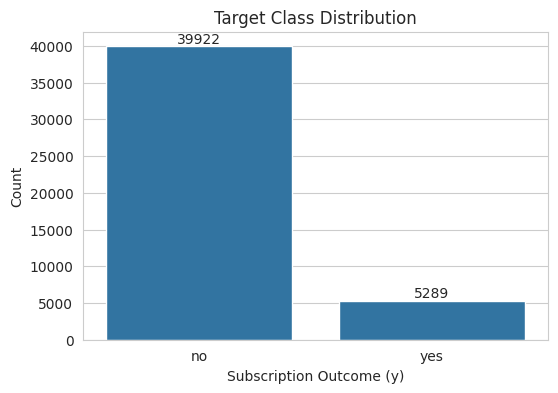

In [16]:
# Target distribution plot

target_counts = df["y"].value_counts()
target_percent = df["y"].value_counts(normalize=True) * 100

print("Target counts:")
print(target_counts)

print("\nTarget percentages:")
print(target_percent.round(2))

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="y")
plt.title("Target Class Distribution")
plt.xlabel("Subscription Outcome (y)")
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")

plt.show()

## **4.2** Subscription rate by job

This cell examines how the subscription rate varies across job categories. It helps identify whether occupation appears to influence the likelihood of subscribing to the term deposit.

Subscription rate by job (%):


,Subscription Rate (%)
job,
student,28.678038
retired,22.791519
unemployed,15.502686
management,13.755551
admin.,12.202669
self-employed,11.842939
unknown,11.805556
technician,11.056996
services,8.883004


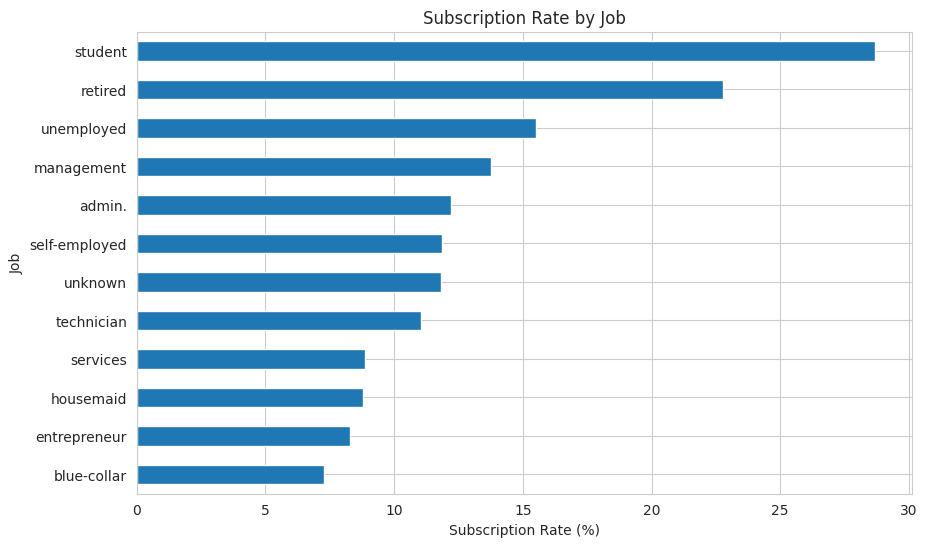

In [17]:
# Subscription rate by job

job_rate = (
    df.groupby("job")["y"]
    .apply(lambda x: (x == "yes").mean())
    .sort_values(ascending=False)
    * 100
)

print("Subscription rate by job (%):")
display(job_rate.to_frame(name="Subscription Rate (%)"))

plt.figure(figsize=(10, 6))
job_rate.plot(kind="barh")
plt.title("Subscription Rate by Job")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Job")
plt.gca().invert_yaxis()  # highest rate at top
plt.show()

## **4.3** Subscription rate by education

This cell compares subscription rates across education levels. It helps reveal whether educational background is associated with different customer response patterns.


Subscription rate by education (%):


,Subscription Rate (%)
education,
tertiary,15.006390
unknown,13.570275
secondary,10.559435
primary,8.626478


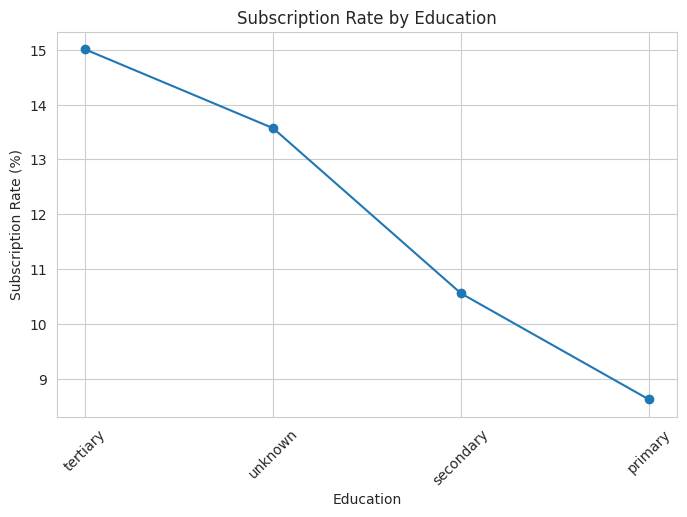

In [18]:
# Subscription rate by education

education_rate = (
    df.groupby("education")["y"]
    .apply(lambda x: (x == "yes").mean())
    .sort_values(ascending=False)
    * 100
)

print("Subscription rate by education (%):")
display(education_rate.to_frame(name="Subscription Rate (%)"))

plt.figure(figsize=(8, 5))
plt.plot(education_rate.index, education_rate.values, marker='o', linestyle='-')
plt.title("Subscription Rate by Education")
plt.xlabel("Education")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=45)
plt.show()

## **4.4** Subscription rate by contact type

This cell investigates whether the communication contact type is associated with customer subscription behaviour. Since the variable contains many 'unknown' values, it is important to understand how this category behaves.

Subscription rate by contact type (%):


,Subscription Rate (%)
contact,
cellular,14.918900
telephone,13.420509
unknown,4.070661


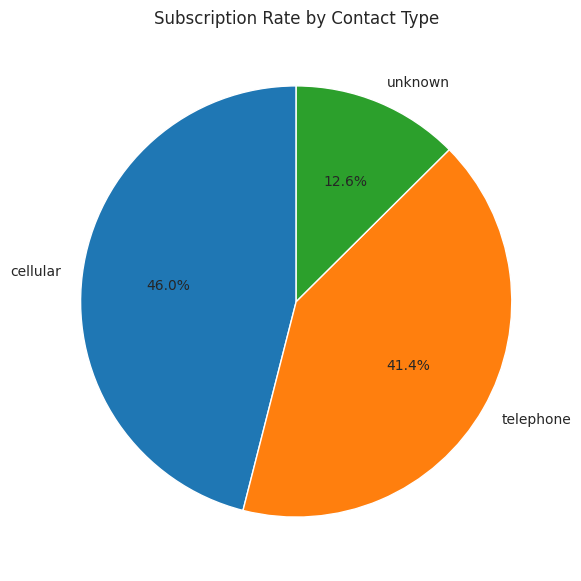

In [19]:
# Subscription rate by contact type

contact_rate = (
    df.groupby("contact")["y"]
    .apply(lambda x: (x == "yes").mean())
    .sort_values(ascending=False)
    * 100
)

print("Subscription rate by contact type (%):")
display(contact_rate.to_frame(name="Subscription Rate (%)"))

plt.figure(figsize=(7, 7))
plt.pie(contact_rate.values, labels=contact_rate.index, autopct='%1.1f%%', startangle=90)
plt.title("Subscription Rate by Contact Type")
plt.show()

## **4.5** Subscription rate by previous campaign outcome

This cell analyses the relationship between the outcome of the previous marketing campaign and the current subscription rate. This variable may be highly informative, even though many observations contain the category 'unknown'.

Subscription rate by previous campaign outcome (%):


,Subscription Rate (%)
poutcome,
success,64.725347
other,16.684783
failure,12.609671
unknown,9.161503


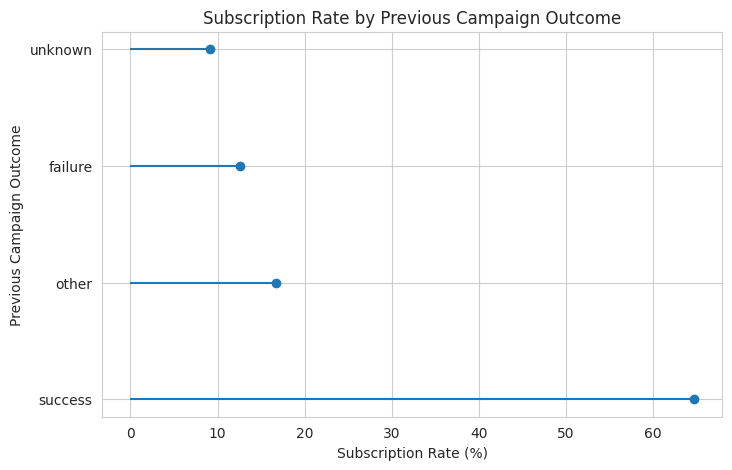

In [20]:
# Subscription rate by previous campaign outcome

poutcome_rate = (
    df.groupby("poutcome")["y"]
    .apply(lambda x: (x == "yes").mean())
    .sort_values(ascending=False)
    * 100
)

print("Subscription rate by previous campaign outcome (%):")
display(poutcome_rate.to_frame(name="Subscription Rate (%)"))

plt.figure(figsize=(8, 5))
plt.hlines(y=poutcome_rate.index, xmin=0, xmax=poutcome_rate.values)
plt.plot(poutcome_rate.values, poutcome_rate.index, "o")
plt.title("Subscription Rate by Previous Campaign Outcome")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Previous Campaign Outcome")
plt.show()

In [21]:
# Compact insight summary

print("Top 3 job categories by subscription rate:")
print(job_rate.head(3).round(2))

print("\nEducation categories by subscription rate:")
print(education_rate.round(2))

print("\nContact types by subscription rate:")
print(contact_rate.round(2))

print("\nPrevious campaign outcome by subscription rate:")
print(poutcome_rate.round(2))

Top 3 job categories by subscription rate:
job
student       28.68
retired       22.79
unemployed    15.50
Name: y, dtype: float64

Education categories by subscription rate:
education
tertiary     15.01
unknown      13.57
secondary    10.56
primary       8.63
Name: y, dtype: float64

Contact types by subscription rate:
contact
cellular     14.92
telephone    13.42
unknown       4.07
Name: y, dtype: float64

Previous campaign outcome by subscription rate:
poutcome
success    64.73
other      16.68
failure    12.61
unknown     9.16
Name: y, dtype: float64


# Section 5: Exploratory Data Analysis (Part 2 - Numerical Features)

In this section, I analyse the numerical features in the Bank Marketing dataset. The aim is to understand their distributions, identify skewness and outliers, compare values across the target classes, and examine correlations between the numerical variables.

In [22]:
# Define numerical feature list for EDA

numerical_features = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
print("Numerical features used for EDA:")
print(numerical_features)

Numerical features used for EDA:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


## **5.1** Histograms of numerical variables

This section visualises the distributions of the numerical variables. It helps identify skewness, concentration of values, and unusually wide ranges that may affect later preprocessing and model training.

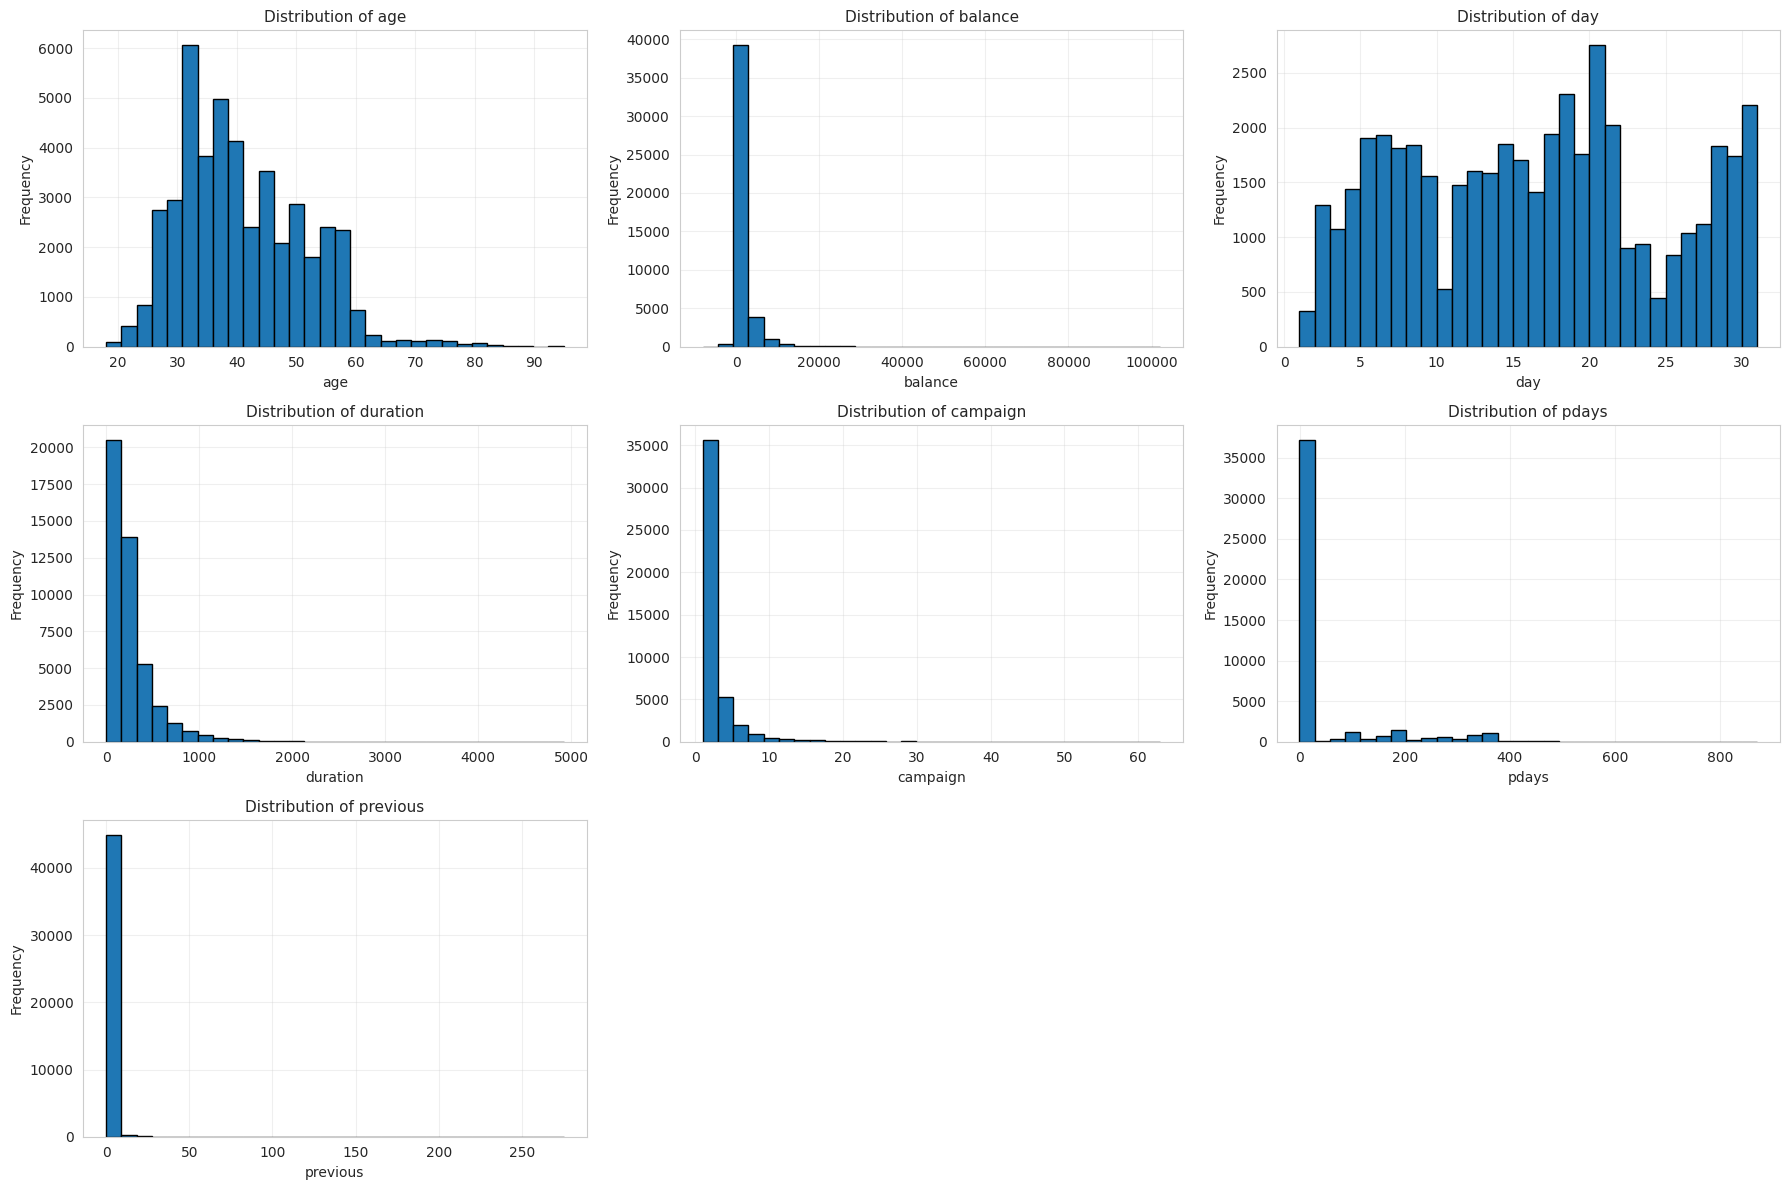

In [23]:
# Histograms for numerical variables

import math

n_cols = 3  # number of plots per row
n_rows = math.ceil(len(numerical_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    axes[i].hist(df[col], bins=30, edgecolor="black")
    axes[i].set_title(f"Distribution of {col}", fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
    axes[i].grid(True, alpha=0.3)

# Removing empty spaces
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## **5.2** Boxplots of numerical variables

This section uses boxplots to identify outliers and spread in the numerical variables. Boxplots are useful for spotting extreme values and comparing the overall scale of each feature.

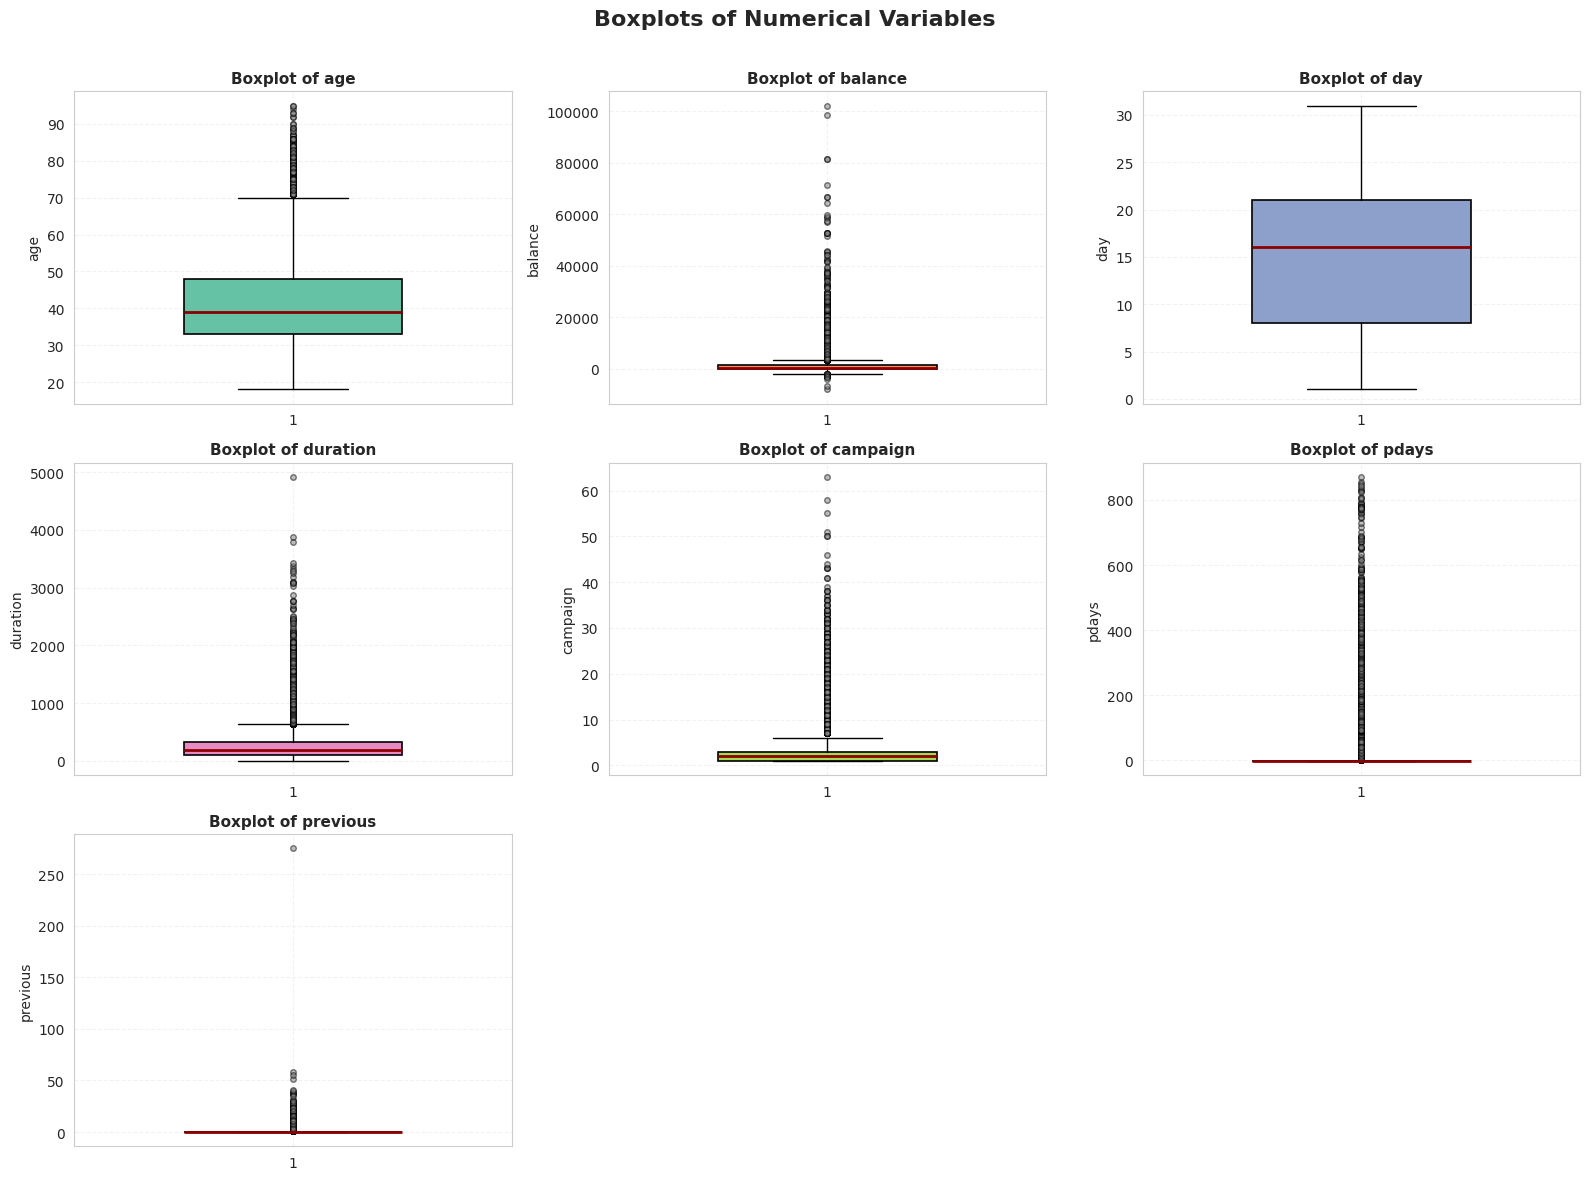

In [24]:
# boxplots of numerical variables

import math

n_cols = 3
n_rows = math.ceil(len(numerical_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854', '#ffd92f',
          '#e5c494', '#b3b3b3', '#1f78b4', '#33a02c', '#fb9a99', '#cab2d6']

for i, col in enumerate(numerical_features):
    bp = axes[i].boxplot(
        df[col].dropna(),
        vert=True,
        patch_artist=True,
        widths=0.5,
        boxprops=dict(facecolor=colors[i % len(colors)], edgecolor='black', linewidth=1.2),
        medianprops=dict(color='darkred', linewidth=2),
        whiskerprops=dict(color='black', linewidth=1),
        capprops=dict(color='black', linewidth=1),
        flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.5)
    )

    axes[i].set_title(f"Boxplot of {col}", fontsize=11, fontweight='bold')
    axes[i].set_ylabel(col)
    axes[i].grid(True, alpha=0.25, linestyle='--')

# Removing empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Boxplots of Numerical Variables", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## **5.3** Compare numerical features by target class

This section compares the mean and median values of numerical variables for customers who subscribed and those who did not subscribe. This helps identify whether numerical features show different patterns across the two classes.

In [25]:
# Mean and median by target class

mean_by_target = df.groupby("y")[numerical_features].mean().T
median_by_target = df.groupby("y")[numerical_features].median().T

print("Mean values by target class:")
display(mean_by_target)

print("\nMedian values by target class:")
display(median_by_target)

Mean values by target class:


y,no,yes
age,40.838986,41.670070
balance,1303.714969,1804.267915
day,15.892290,15.158253
duration,221.182806,537.294574
campaign,2.846350,2.141047
pdays,36.421372,68.702968
previous,0.502154,1.170354



Median values by target class:


y,no,yes
age,39.0,38.0
balance,417.0,733.0
day,16.0,15.0
duration,164.0,426.0
campaign,2.0,2.0
pdays,-1.0,-1.0
previous,0.0,0.0


## **5.4** Bar chart comparison of means by target class

This plot compares the average values of the numerical features across the target classes. It provides a quick visual indication of which variables may separate subscribers from non-subscribers.

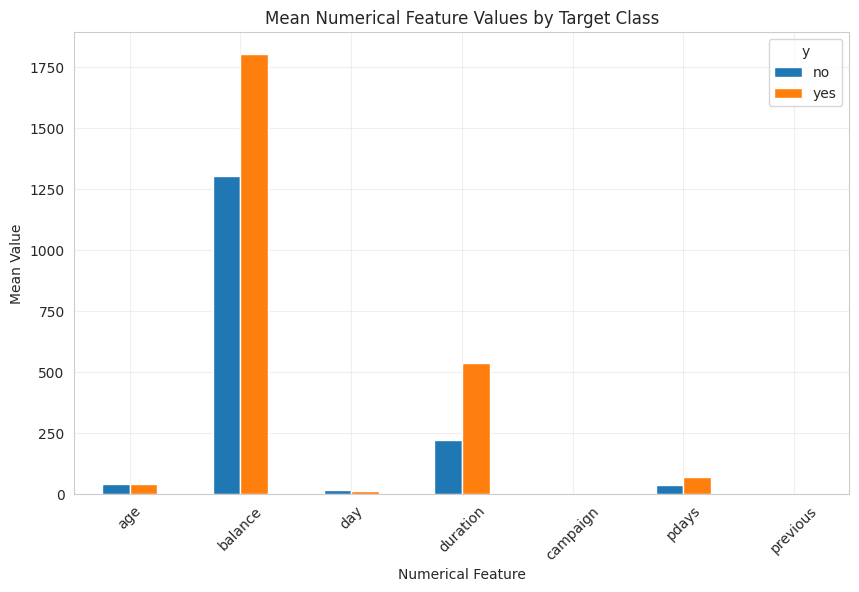

In [26]:
# Plot mean comparison by target class

mean_by_target.plot(kind="bar", figsize=(10, 6))
plt.title("Mean Numerical Feature Values by Target Class")
plt.xlabel("Numerical Feature")
plt.ylabel("Mean Value")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

## **5.5** Numerical feature correlation matrix

This section examines linear relationships between the numerical variables using a correlation matrix. Strong correlations may indicate redundancy or interaction between features.

Correlation matrix:


,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.097783,-0.009120,-0.004648,0.004760,-0.023758,0.001288
balance,0.097783,1.000000,0.004503,0.021560,-0.014578,0.003435,0.016674
day,-0.009120,0.004503,1.000000,-0.030206,0.162490,-0.093044,-0.051710
duration,-0.004648,0.021560,-0.030206,1.000000,-0.084570,-0.001565,0.001203
campaign,0.004760,-0.014578,0.162490,-0.084570,1.000000,-0.088628,-0.032855
pdays,-0.023758,0.003435,-0.093044,-0.001565,-0.088628,1.000000,0.454820
previous,0.001288,0.016674,-0.051710,0.001203,-0.032855,0.454820,1.000000


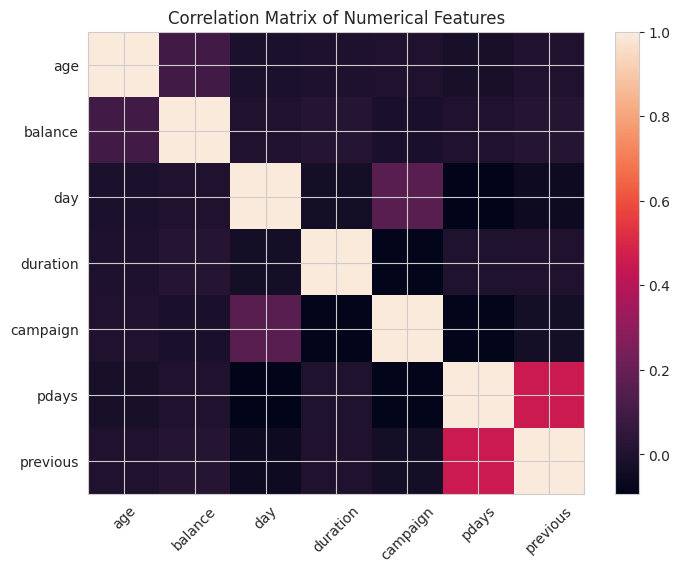

In [27]:
# Correlation matrix

corr_matrix = df[numerical_features].corr()

print("Correlation matrix:")
display(corr_matrix)

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, interpolation="nearest", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

## **5.6** Target-wise boxplots and histograms  for key numerical features

This section compares the distributions of selected numerical variables across the target classes. These visual comparisons help show whether customers who subscribed differ from those who did not in terms of age, balance, campaign duration, and contact history.

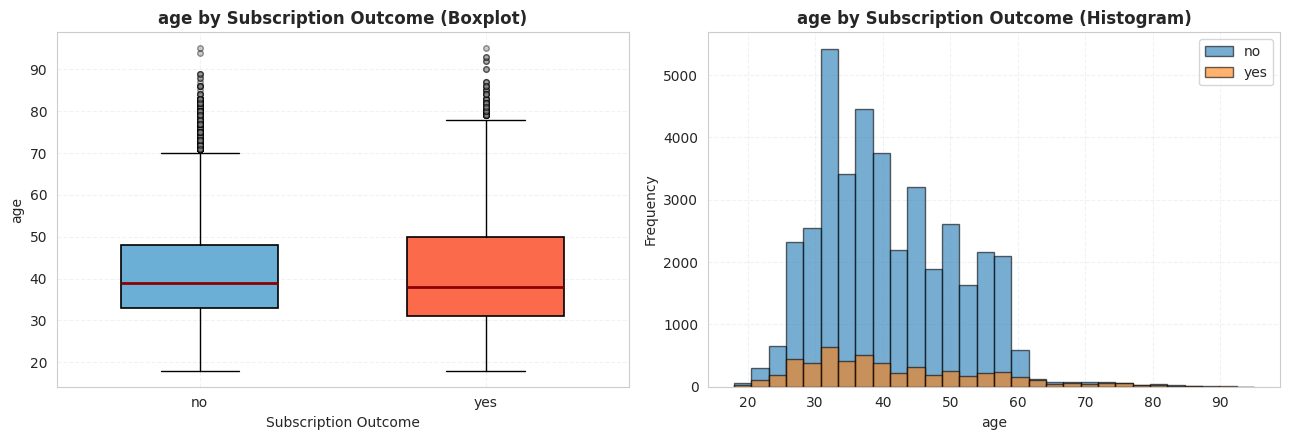

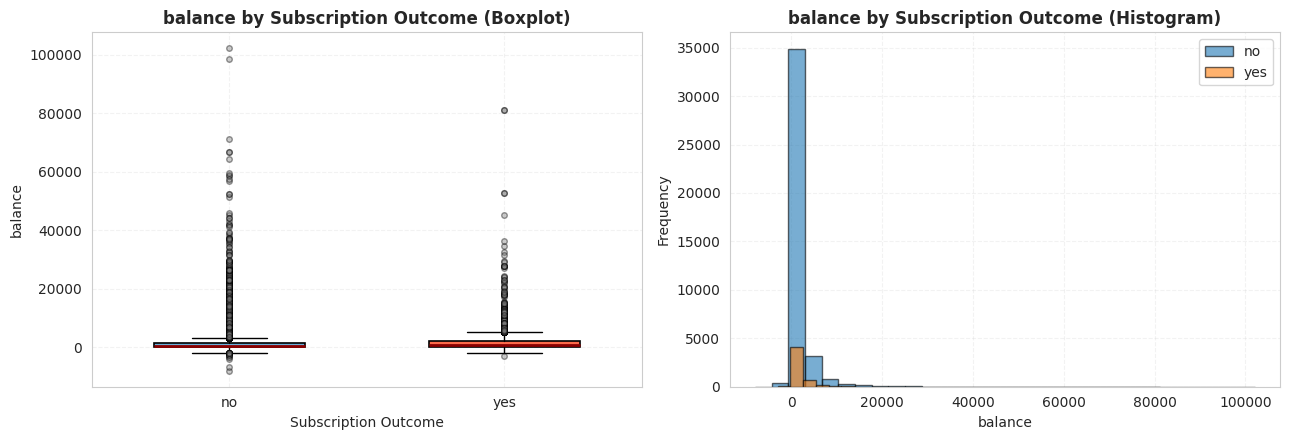

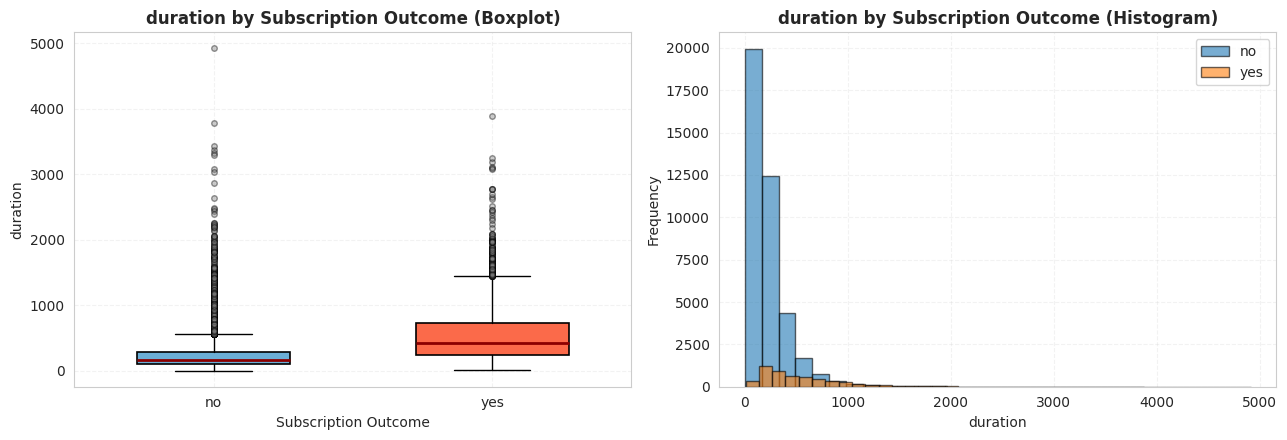

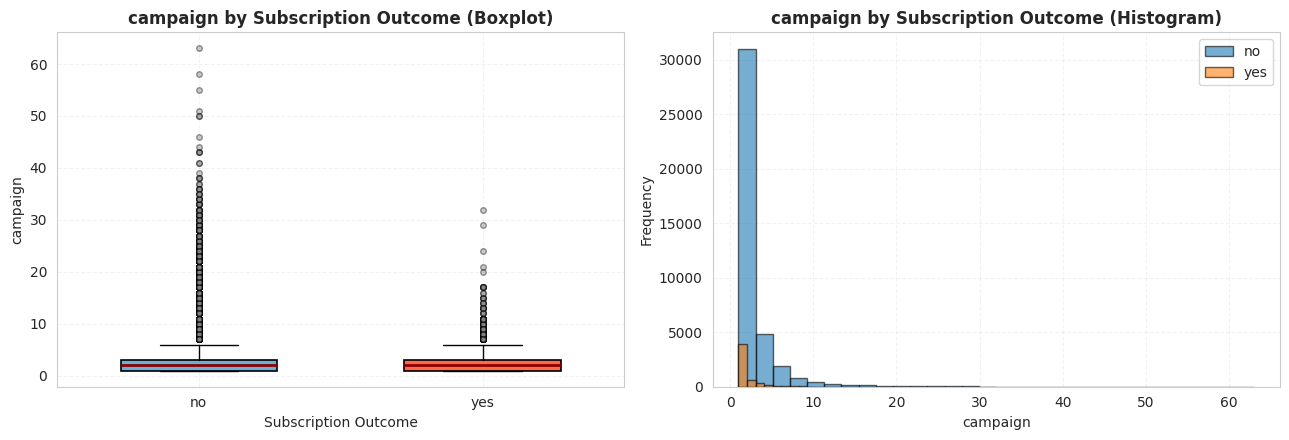

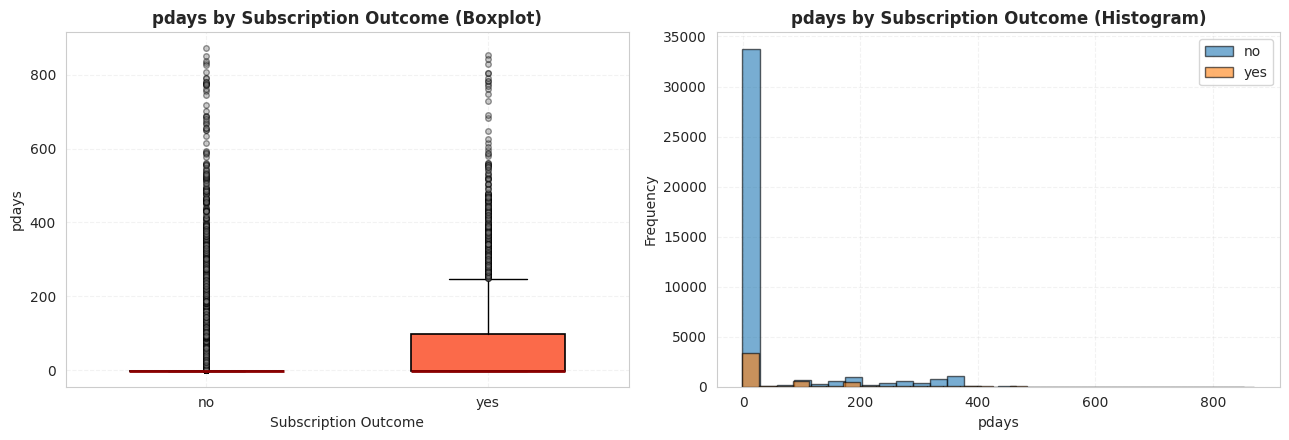

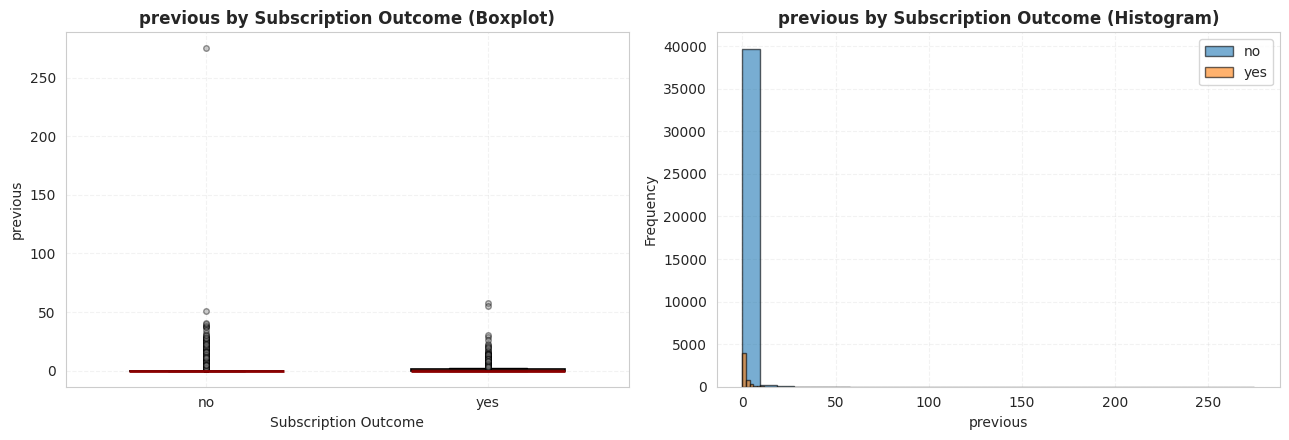

In [28]:
# Compare selected numerical features against target

key_numeric = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

colors = ["#6baed6", "#fb6a4a"]  # no, yes

for col in key_numeric:
    no_vals = df[df["y"] == "no"][col].dropna()
    yes_vals = df[df["y"] == "yes"][col].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    # Left: boxplot
    bp = axes[0].boxplot(
        [no_vals, yes_vals],
        tick_labels=["no", "yes"],
        patch_artist=True,
        widths=0.55,
        boxprops=dict(edgecolor="black", linewidth=1.2),
        medianprops=dict(color="darkred", linewidth=2),
        whiskerprops=dict(color="black", linewidth=1),
        capprops=dict(color="black", linewidth=1),
        flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.4)
    )

    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)

    axes[0].set_title(f"{col} by Subscription Outcome (Boxplot)", fontweight="bold")
    axes[0].set_xlabel("Subscription Outcome")
    axes[0].set_ylabel(col)
    axes[0].grid(True, alpha=0.25, linestyle="--")

    # Right: overlaid histogram
    axes[1].hist(no_vals, bins=30, alpha=0.6, label="no", edgecolor="black")
    axes[1].hist(yes_vals, bins=30, alpha=0.6, label="yes", edgecolor="black")
    axes[1].set_title(f"{col} by Subscription Outcome (Histogram)", fontweight="bold")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Frequency")
    axes[1].legend()
    axes[1].grid(True, alpha=0.25, linestyle="--")

    plt.tight_layout()
    plt.show()

## 5.7 Numerical EDA summary

This section prints a compact summary of the key numerical trends identified so far.

In [29]:
# Compact numerical summary

print("Mean values by target class:")
print(mean_by_target.round(2))

print("\nMedian values by target class:")
print(median_by_target.round(2))

print("\nCorrelation with duration:")
print(corr_matrix["duration"].sort_values(ascending=False).round(3))

print("\nCorrelation with balance:")
print(corr_matrix["balance"].sort_values(ascending=False).round(3))

Mean values by target class:
y              no      yes
age         40.84    41.67
balance   1303.71  1804.27
day         15.89    15.16
duration   221.18   537.29
campaign     2.85     2.14
pdays       36.42    68.70
previous     0.50     1.17

Median values by target class:
y            no    yes
age        39.0   38.0
balance   417.0  733.0
day        16.0   15.0
duration  164.0  426.0
campaign    2.0    2.0
pdays      -1.0   -1.0
previous    0.0    0.0

Correlation with duration:
duration    1.000
balance     0.022
previous    0.001
pdays      -0.002
age        -0.005
day        -0.030
campaign   -0.085
Name: duration, dtype: float64

Correlation with balance:
balance     1.000
age         0.098
duration    0.022
previous    0.017
day         0.005
pdays       0.003
campaign   -0.015
Name: balance, dtype: float64


# Section 6: Preprocessing Design and Feature Decisions

In this section, I prepare the dataset for machine learning by defining the target variable, creating a modelling copy of the data, and deciding how key features should be handled. Special attention is given to the variable `pdays`, which uses `-1` as a coded value, and to the variable `duration`, which will later be tested both with and without inclusion in the model.

In [30]:
# Create a modelling copy

df_model = df.copy()

print("Modelling dataset created.")
print("Shape:", df_model.shape)

Modelling dataset created.
Shape: (45211, 17)


## **6.1** Encode the target variable

This cell converts the target column into binary format so that it can be used in neural network training. The value `yes` is encoded as 1 and `no` is encoded as 0.

In [31]:
# Encode target

df_model["y_binary"] = df_model["y"].map({"no": 0, "yes": 1})

print("Target encoding completed.")
print(df_model[["y", "y_binary"]].head())

print("\nEncoded target distribution:")
print(df_model["y_binary"].value_counts())

Target encoding completed.
    y  y_binary
0  no         0
1  no         0
2  no         0
3  no         0
4  no         0

Encoded target distribution:
y_binary
0    39922
1     5289
Name: count, dtype: int64


## **6.2** Handle the special coded variable `pdays`

In the original dataset, `pdays = -1` indicates that the customer was not previously contacted. This is not a normal numerical value, so I create two new variables: one binary indicator showing whether the customer was previously contacted, and one cleaned numerical version of `pdays` where `-1` is replaced with 0.

In [32]:
# Handle pdays special coding

df_model["was_previously_contacted"] = (df_model["pdays"] != -1).astype(int)
df_model["pdays_clean"] = df_model["pdays"].replace(-1, 0)

print("New pdays-related features created.\n")

display(df_model[["pdays", "was_previously_contacted", "pdays_clean"]].head(10))

print("\nPreviously contacted flag counts:")
print(df_model["was_previously_contacted"].value_counts())

print("\nSummary of pdays_clean:")
display(df_model["pdays_clean"].describe())

New pdays-related features created.



,pdays,was_previously_contacted,pdays_clean
0,-1,0,0
1,-1,0,0
2,-1,0,0
3,-1,0,0
4,-1,0,0
5,-1,0,0
6,-1,0,0
7,-1,0,0
8,-1,0,0
9,-1,0,0



Previously contacted flag counts:
was_previously_contacted
0    36954
1     8257
Name: count, dtype: int64

Summary of pdays_clean:


,pdays_clean
count,45211.000000
mean,41.015195
std,99.792615
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,871.000000


## **6.3** Define candidate input features

This cell defines the modelling feature sets. The original target column is removed, and the raw `pdays` variable is replaced by the engineered variables. Two feature versions are created: one including `duration` and one excluding it for comparison.

In [33]:
# Define feature sets

all_candidate_features = [col for col in df_model.columns if col not in ["y", "y_binary", "pdays"]]

features_with_duration = all_candidate_features.copy()
features_without_duration = [col for col in all_candidate_features if col != "duration"]

print("Number of features WITH duration:", len(features_with_duration))
print("Number of features WITHOUT duration:", len(features_without_duration))

print("\nFeatures WITH duration:")
print(features_with_duration)

print("\nFeatures WITHOUT duration:")
print(features_without_duration)

Number of features WITH duration: 17
Number of features WITHOUT duration: 16

Features WITH duration:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'previous', 'poutcome', 'was_previously_contacted', 'pdays_clean']

Features WITHOUT duration:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'previous', 'poutcome', 'was_previously_contacted', 'pdays_clean']


## 6.4 Separate numerical and categorical features for each model version

This cell identifies which features are numerical and which are categorical. This is necessary because numerical variables will be scaled, while categorical variables will be encoded separately.

In [34]:
# Separate numerical and categorical features

numerical_with_duration = [
    "age", "balance", "day", "duration", "campaign", "previous",
    "was_previously_contacted", "pdays_clean"
]

categorical_with_duration = [col for col in features_with_duration if col not in numerical_with_duration]

numerical_without_duration = [
    "age", "balance", "day", "campaign", "previous",
    "was_previously_contacted", "pdays_clean"
]

categorical_without_duration = [col for col in features_without_duration if col not in numerical_without_duration]

print("Numerical features WITH duration:")
print(numerical_with_duration)

print("\nCategorical features WITH duration:")
print(categorical_with_duration)

print("\nNumerical features WITHOUT duration:")
print(numerical_without_duration)

print("\nCategorical features WITHOUT duration:")
print(categorical_without_duration)

Numerical features WITH duration:
['age', 'balance', 'day', 'duration', 'campaign', 'previous', 'was_previously_contacted', 'pdays_clean']

Categorical features WITH duration:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Numerical features WITHOUT duration:
['age', 'balance', 'day', 'campaign', 'previous', 'was_previously_contacted', 'pdays_clean']

Categorical features WITHOUT duration:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


## 6.5 Create modelling matrices

This cell creates the final input matrices and target vector that will be used in later training and evaluation stages.

In [35]:
#  Create X and y objects

X_with_duration = df_model[features_with_duration].copy()
X_without_duration = df_model[features_without_duration].copy()
y = df_model["y_binary"].copy()

print("Shapes:")
print("X_with_duration:", X_with_duration.shape)
print("X_without_duration:", X_without_duration.shape)
print("y:", y.shape)

Shapes:
X_with_duration: (45211, 17)
X_without_duration: (45211, 16)
y: (45211,)


## 6.6 Preprocessing decision summary

This cell records the final preprocessing design decisions that will be used in the next stages of the project.

In [36]:
#  Preprocessing summary table

prep_summary = pd.DataFrame({
    "Decision Area": [
        "Target encoding",
        "Missing values",
        "Duplicates",
        "Unknown categories",
        "Special handling for pdays",
        "Duration comparison",
        "Categorical preprocessing",
        "Numerical preprocessing",
        "Class imbalance"
    ],
    "Decision": [
        "Encode y as 0/1",
        "No null values found",
        "No duplicates found",
        "Keep 'unknown' as a valid category",
        "Create was_previously_contacted and pdays_clean",
        "Train models with and without duration",
        "Use one-hot encoding later",
        "Scale numerical variables later",
        "Use stratified split and handle imbalance during training"
    ]
})

display(prep_summary)

,Decision Area,Decision
0,Target encoding,Encode y as 0/1
1,Missing values,No null values found
2,Duplicates,No duplicates found
3,Unknown categories,Keep 'unknown' as a valid category
4,Special handling for pdays,Create was_previously_contacted and pdays_clean
5,Duration comparison,Train models with and without duration
6,Categorical preprocessing,Use one-hot encoding later
7,Numerical preprocessing,Scale numerical variables later
8,Class imbalance,Use stratified split and handle imbalance duri...


# Section 7: Train, Validation, and Test Split

In this section, I divide the dataset into training, validation, and test sets. A stratified split is used to preserve the class imbalance ratio across all subsets. This ensures that model development, tuning, and final evaluation are carried out on separate data partitions.

#  7.1 - Import splitting function

from sklearn.model_selection import train_test_split

print("train_test_split imported successfully.")

In [37]:
#  Import splitting function

from sklearn.model_selection import train_test_split

print("train_test_split imported successfully.")

train_test_split imported successfully.


#  7.2 - Split data WITH duration

In [38]:
# Section 7.2 - Split data WITH duration

# Step 1: train vs temp
X_train_wd, X_temp_wd, y_train_wd, y_temp_wd = train_test_split(
    X_with_duration,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Step 2: validation vs test from temp
X_val_wd, X_test_wd, y_val_wd, y_test_wd = train_test_split(
    X_temp_wd,
    y_temp_wd,
    test_size=0.50,
    stratify=y_temp_wd,
    random_state=42
)

print("WITH duration split completed.")
print("X_train_wd:", X_train_wd.shape)
print("X_val_wd:", X_val_wd.shape)
print("X_test_wd:", X_test_wd.shape)
print("y_train_wd:", y_train_wd.shape)
print("y_val_wd:", y_val_wd.shape)
print("y_test_wd:", y_test_wd.shape)

WITH duration split completed.
X_train_wd: (31647, 17)
X_val_wd: (6782, 17)
X_test_wd: (6782, 17)
y_train_wd: (31647,)
y_val_wd: (6782,)
y_test_wd: (6782,)


## 7.3 Split the dataset without the duration feature

This cell creates train, validation, and test sets for the feature version that excludes `duration`. The same stratified splitting strategy is used to ensure a fair comparison between the two model versions.

In [39]:
# Split data WITHOUT duration

# Step 1: train vs temp
X_train_wod, X_temp_wod, y_train_wod, y_temp_wod = train_test_split(
    X_without_duration,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Step 2: validation vs test from temp
X_val_wod, X_test_wod, y_val_wod, y_test_wod = train_test_split(
    X_temp_wod,
    y_temp_wod,
    test_size=0.50,
    stratify=y_temp_wod,
    random_state=42
)

print("WITHOUT duration split completed.")
print("X_train_wod:", X_train_wod.shape)
print("X_val_wod:", X_val_wod.shape)
print("X_test_wod:", X_test_wod.shape)
print("y_train_wod:", y_train_wod.shape)
print("y_val_wod:", y_val_wod.shape)
print("y_test_wod:", y_test_wod.shape)

WITHOUT duration split completed.
X_train_wod: (31647, 16)
X_val_wod: (6782, 16)
X_test_wod: (6782, 16)
y_train_wod: (31647,)
y_val_wod: (6782,)
y_test_wod: (6782,)


## 7.4 Check class balance across splits

This cell verifies that the stratified split preserved the class distribution in the training, validation, and test sets. This is important because the target variable is imbalanced.

In [40]:
#  Function to check class balance

def class_distribution_report(name, y_series):
    counts = y_series.value_counts().sort_index()
    props = (y_series.value_counts(normalize=True).sort_index() * 100).round(2)

    print(f"\n{name}")
    print("Counts:")
    print(counts)
    print("Percentages:")
    print(props)

print("WITH duration - class balance check")
class_distribution_report("y_train_wd", y_train_wd)
class_distribution_report("y_val_wd", y_val_wd)
class_distribution_report("y_test_wd", y_test_wd)

print("\n" + "="*50)
print("WITHOUT duration - class balance check")
class_distribution_report("y_train_wod", y_train_wod)
class_distribution_report("y_val_wod", y_val_wod)
class_distribution_report("y_test_wod", y_test_wod)

WITH duration - class balance check

y_train_wd
Counts:
y_binary
0    27945
1     3702
Name: count, dtype: int64
Percentages:
y_binary
0    88.3
1    11.7
Name: proportion, dtype: float64

y_val_wd
Counts:
y_binary
0    5988
1     794
Name: count, dtype: int64
Percentages:
y_binary
0    88.29
1    11.71
Name: proportion, dtype: float64

y_test_wd
Counts:
y_binary
0    5989
1     793
Name: count, dtype: int64
Percentages:
y_binary
0    88.31
1    11.69
Name: proportion, dtype: float64

WITHOUT duration - class balance check

y_train_wod
Counts:
y_binary
0    27945
1     3702
Name: count, dtype: int64
Percentages:
y_binary
0    88.3
1    11.7
Name: proportion, dtype: float64

y_val_wod
Counts:
y_binary
0    5988
1     794
Name: count, dtype: int64
Percentages:
y_binary
0    88.29
1    11.71
Name: proportion, dtype: float64

y_test_wod
Counts:
y_binary
0    5989
1     793
Name: count, dtype: int64
Percentages:
y_binary
0    88.31
1    11.69
Name: proportion, dtype: float64


## 7.5 Confirm split proportions

This cell calculates the relative size of each subset to confirm that the data has been divided into approximately 70% training, 15% validation, and 15% test data.

In [41]:
# Confirm split proportions

total_rows = len(y)

split_summary = pd.DataFrame({
    "Subset": ["Train", "Validation", "Test"],
    "Rows (with duration)": [len(y_train_wd), len(y_val_wd), len(y_test_wd)],
    "Percentage (with duration)": [
        round(len(y_train_wd) / total_rows * 100, 2),
        round(len(y_val_wd) / total_rows * 100, 2),
        round(len(y_test_wd) / total_rows * 100, 2),
    ],
    "Rows (without duration)": [len(y_train_wod), len(y_val_wod), len(y_test_wod)],
    "Percentage (without duration)": [
        round(len(y_train_wod) / total_rows * 100, 2),
        round(len(y_val_wod) / total_rows * 100, 2),
        round(len(y_test_wod) / total_rows * 100, 2),
    ]
})

display(split_summary)

,Subset,Rows (with duration),Percentage (with duration),Rows (without duration),Percentage (without duration)
0,Train,31647,70.0,31647,70.0
1,Validation,6782,15.0,6782,15.0
2,Test,6782,15.0,6782,15.0


## 7.6 Split summary interpretation

This cell prints a compact interpretation of the splitting strategy used for the modelling workflow.

In [42]:
# Section 7.6 - Interpretation

print("Data splitting summary:")
print("- The dataset has been divided into training, validation, and test subsets.")
print("- Stratification has been used to preserve class imbalance ratios.")
print("- Separate splits have been created for both feature versions.")
print("- The test set will remain untouched until final evaluation.")

Data splitting summary:
- The dataset has been divided into training, validation, and test subsets.
- Stratification has been used to preserve class imbalance ratios.
- Separate splits have been created for both feature versions.
- The test set will remain untouched until final evaluation.


# Section 8: Encoding and Scaling

In this section, I preprocess the input features for neural network training. Categorical variables are transformed using one-hot encoding, while numerical variables are standardised using feature scaling. The preprocessing steps are fitted only on the training set to avoid data leakage, and then applied to the validation and test sets for both model versions.

In [43]:
#  Encoding and scaling for both model versions

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np


# 1. Build preprocessors

preprocessor_wd = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_with_duration),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_with_duration)
    ]
)

preprocessor_wod = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_without_duration),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_without_duration)
    ]
)


# 2. Fit on training data only

X_train_wd_processed = preprocessor_wd.fit_transform(X_train_wd)
X_val_wd_processed   = preprocessor_wd.transform(X_val_wd)
X_test_wd_processed  = preprocessor_wd.transform(X_test_wd)

X_train_wod_processed = preprocessor_wod.fit_transform(X_train_wod)
X_val_wod_processed   = preprocessor_wod.transform(X_val_wod)
X_test_wod_processed  = preprocessor_wod.transform(X_test_wod)


# 3. Convert to float32 for ANN

X_train_wd_processed = np.asarray(X_train_wd_processed, dtype=np.float32)
X_val_wd_processed   = np.asarray(X_val_wd_processed, dtype=np.float32)
X_test_wd_processed  = np.asarray(X_test_wd_processed, dtype=np.float32)

X_train_wod_processed = np.asarray(X_train_wod_processed, dtype=np.float32)
X_val_wod_processed   = np.asarray(X_val_wod_processed, dtype=np.float32)
X_test_wod_processed  = np.asarray(X_test_wod_processed, dtype=np.float32)

y_train_wd_np = np.asarray(y_train_wd, dtype=np.float32)
y_val_wd_np   = np.asarray(y_val_wd, dtype=np.float32)
y_test_wd_np  = np.asarray(y_test_wd, dtype=np.float32)

y_train_wod_np = np.asarray(y_train_wod, dtype=np.float32)
y_val_wod_np   = np.asarray(y_val_wod, dtype=np.float32)
y_test_wod_np  = np.asarray(y_test_wod, dtype=np.float32)


# 4. Get transformed feature names

feature_names_wd = preprocessor_wd.get_feature_names_out()
feature_names_wod = preprocessor_wod.get_feature_names_out()

# 5. Print summary

print("WITH duration - processed shapes")
print("X_train_wd_processed:", X_train_wd_processed.shape)
print("X_val_wd_processed:  ", X_val_wd_processed.shape)
print("X_test_wd_processed: ", X_test_wd_processed.shape)

print("\nWITHOUT duration - processed shapes")
print("X_train_wod_processed:", X_train_wod_processed.shape)
print("X_val_wod_processed:  ", X_val_wod_processed.shape)
print("X_test_wod_processed: ", X_test_wod_processed.shape)

print("\nSample transformed feature names WITH duration:")
print(feature_names_wd[:20])

print("\nSample transformed feature names WITHOUT duration:")
print(feature_names_wod[:20])

print("\nData types after processing:")
print("WITH duration:", X_train_wd_processed.dtype)
print("WITHOUT duration:", X_train_wod_processed.dtype)

print("\nNaN check:")
print("WITH duration - train NaNs:", np.isnan(X_train_wd_processed).sum())
print("WITHOUT duration - train NaNs:", np.isnan(X_train_wod_processed).sum())

WITH duration - processed shapes
X_train_wd_processed: (31647, 52)
X_val_wd_processed:   (6782, 52)
X_test_wd_processed:  (6782, 52)

WITHOUT duration - processed shapes
X_train_wod_processed: (31647, 51)
X_val_wod_processed:   (6782, 51)
X_test_wod_processed:  (6782, 51)

Sample transformed feature names WITH duration:
['num__age' 'num__balance' 'num__day' 'num__duration' 'num__campaign'
 'num__previous' 'num__was_previously_contacted' 'num__pdays_clean'
 'cat__job_admin.' 'cat__job_blue-collar' 'cat__job_entrepreneur'
 'cat__job_housemaid' 'cat__job_management' 'cat__job_retired'
 'cat__job_self-employed' 'cat__job_services' 'cat__job_student'
 'cat__job_technician' 'cat__job_unemployed' 'cat__job_unknown']

Sample transformed feature names WITHOUT duration:
['num__age' 'num__balance' 'num__day' 'num__campaign' 'num__previous'
 'num__was_previously_contacted' 'num__pdays_clean' 'cat__job_admin.'
 'cat__job_blue-collar' 'cat__job_entrepreneur' 'cat__job_housemaid'
 'cat__job_managemen

## Check the final ANN-ready matrices

This cell confirms that the processed feature matrices are fully numeric and ready to be used as inputs for neural network training.

In [44]:
print("First 3 rows of processed WITH-duration matrix:")
print(X_train_wd_processed[:3, :10])

print("\nFirst 3 rows of processed WITHOUT-duration matrix:")
print(X_train_wod_processed[:3, :10])

First 3 rows of processed WITH-duration matrix:
[[-0.93046093 -0.44381323 -0.8170392  -0.6801517  -0.5668498  -0.23477381
  -0.470453   -0.4095985   0.          0.        ]
 [-0.55387133 -0.3806249   0.14323561 -0.21454513 -0.5668498  -0.23477381
  -0.470453   -0.4095985   0.          0.        ]
 [-1.5894928  -0.41905904  0.02320126 -0.08756152 -0.24478345 -0.23477381
  -0.470453   -0.4095985   0.          1.        ]]

First 3 rows of processed WITHOUT-duration matrix:
[[-0.93046093 -0.44381323 -0.8170392  -0.5668498  -0.23477381 -0.470453
  -0.4095985   0.          0.          0.        ]
 [-0.55387133 -0.3806249   0.14323561 -0.5668498  -0.23477381 -0.470453
  -0.4095985   0.          0.          0.        ]
 [-1.5894928  -0.41905904  0.02320126 -0.24478345 -0.23477381 -0.470453
  -0.4095985   0.          1.          0.        ]]


# Section 9: Baseline MLP ANN Model (With Duration)

In this section, I build and train a baseline Multi-Layer Perceptron (MLP) using the feature set that includes the `duration` variable. This model serves as the first neural network benchmark before introducing additional comparison models and improved regularisation techniques.

All required Section 8 variables are available.
Baseline MLP model built successfully.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,241 (8.75 KB)

 Trainable params: 2,241 (8.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
989/989 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8971 - auc: 0.8889 - loss: 0.2425 - precision: 0.6085 - recall: 0.3379 - val_accuracy: 0.9030 - val_auc: 0.9167 - val_loss: 0.2161 - val_precision: 0.6388 - val_recall: 0.3942
Epoch 2/15
989/989 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9041 - auc: 0.9181 - loss: 0.2149 - precision: 0.6275 - recall: 0.4433 - val_accuracy: 0.9073 - val_auc: 0.9207 - val_loss: 0.2124 - val_precision: 0.6627 - val_recall: 0.4232
Epoch 3/15
989/989 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9058 - auc: 0.9237 - loss: 0.2087 - precision: 0.6335 - recall: 0.4627 - val_accuracy: 0.9084 - val_auc: 0.9230 - val_loss: 0.2094 - val_precision: 0.6629 - val_recall: 0.4433
Epoch 4/15
989/989 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9076 - auc: 0.9276 - loss: 0.2040 - precision: 0.6399 - recall: 0.4800 - val_accuracy: 0.9071 - val_auc: 0.9250 - val_loss: 0.2074 - val_precision: 0.6513 - val_recall: 0.4446
Epoch 5/15
989/989 ━━━━━━━━━━━━━

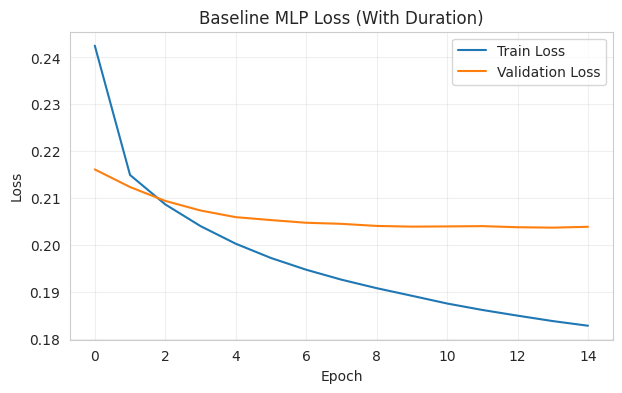

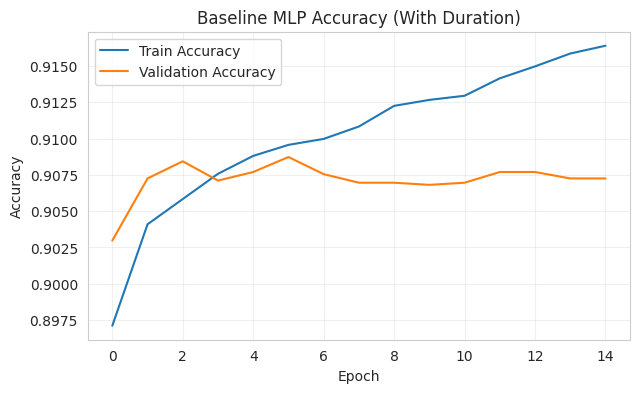


Baseline MLP validation performance:


,Metric,Validation Score
0,loss,0.203872
1,accuracy,0.907255
2,precision,0.641509
3,recall,0.471033
4,auc,0.928587



First 10 validation probabilities:
[0.0036 0.0004 0.0707 0.0096 0.0036 0.001  0.0521 0.0006 0.0194 0.0616]

First 10 validation predictions:
[0 0 0 0 0 0 0 0 0 0]

Final epoch summary:
Train loss: 0.1828
Val loss: 0.2039
Train accuracy: 0.9164
Val accuracy: 0.9073


In [45]:
#  Baseline MLP ANN with duration (robust rerun version)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import BinaryAccuracy, Precision, Recall, AUC

# 0. Safety checks

required_vars = [
    "X_train_wd_processed", "X_val_wd_processed",
    "y_train_wd_np", "y_val_wd_np"
]

missing_vars = [var for var in required_vars if var not in globals()]
if missing_vars:
    raise ValueError(
        f"These variables are missing: {missing_vars}. "
        "Please re-run Section 8 first."
    )

print("All required Section 8 variables are available.")


# 1. Clear old TensorFlow state and set seed

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)


# 2. Build baseline MLP model

baseline_mlp_wd = Sequential([
    Input(shape=(X_train_wd_processed.shape[1],)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

baseline_mlp_wd.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        BinaryAccuracy(name="accuracy"),
        Precision(name="precision"),
        Recall(name="recall"),
        AUC(name="auc")
    ]
)

print("Baseline MLP model built successfully.\n")
baseline_mlp_wd.summary()


# 3. Train model

history_baseline_mlp_wd = baseline_mlp_wd.fit(
    X_train_wd_processed,
    y_train_wd_np,
    validation_data=(X_val_wd_processed, y_val_wd_np),
    epochs=15,
    batch_size=32,
    verbose=1
)


# 4. Plot training history

history_df = pd.DataFrame(history_baseline_mlp_wd.history)

plt.figure(figsize=(7, 4))
plt.plot(history_df["loss"], label="Train Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.title("Baseline MLP Loss (With Duration)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_df["accuracy"], label="Train Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.title("Baseline MLP Accuracy (With Duration)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# 5. Evaluate on validation set

val_results_baseline_mlp_wd = baseline_mlp_wd.evaluate(
    X_val_wd_processed,
    y_val_wd_np,
    verbose=0
)

metric_names = ["loss", "accuracy", "precision", "recall", "auc"]
baseline_val_metrics_mlp_wd = pd.DataFrame({
    "Metric": metric_names,
    "Validation Score": val_results_baseline_mlp_wd
})

print("\nBaseline MLP validation performance:")
display(baseline_val_metrics_mlp_wd)


# 6. Save validation predictions

val_probs_baseline_mlp_wd = baseline_mlp_wd.predict(
    X_val_wd_processed,
    verbose=0
).ravel()

val_preds_baseline_mlp_wd = (val_probs_baseline_mlp_wd >= 0.5).astype(int)

print("\nFirst 10 validation probabilities:")
print(np.round(val_probs_baseline_mlp_wd[:10], 4))

print("\nFirst 10 validation predictions:")
print(val_preds_baseline_mlp_wd[:10])


# 7. Final epoch summary

print("\nFinal epoch summary:")
print("Train loss:", round(history_df['loss'].iloc[-1], 4))
print("Val loss:", round(history_df['val_loss'].iloc[-1], 4))
print("Train accuracy:", round(history_df['accuracy'].iloc[-1], 4))
print("Val accuracy:", round(history_df['val_accuracy'].iloc[-1], 4))

# Section 10 - SLP baseline with duration

All required variables are available.
SLP model built successfully.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            53 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53 (212.00 B)

 Trainable params: 53 (212.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
989/989 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8640 - auc: 0.7824 - loss: 0.3381 - precision: 0.3667 - recall: 0.2239 - val_accuracy: 0.8910 - val_auc: 0.8908 - val_loss: 0.2619 - val_precision: 0.6536 - val_recall: 0.1474
Epoch 2/15
989/989 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8966 - auc: 0.8949 - loss: 0.2554 - precision: 0.6737 - recall: 0.2258 - val_accuracy: 0.8991 - val_auc: 0.9048 - val_loss: 0.2460 - val_precision: 0.6910 - val_recall: 0.2506
Epoch 3/15
989/989 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8997 - auc: 0.9030 - loss: 0.2460 - precision: 0.6665 - recall: 0.2855 - val_accuracy: 0.8999 - val_auc: 0.9071 - val_loss: 0.2411 - val_precision: 0.6716 - val_recall: 0.2834
Epoch 4/15
989/989 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9008 - auc: 0.9056 - loss: 0.2426 - precision: 0.6617 - recall: 0.3117 - val_accuracy: 0.9008 - val_auc: 0.9083 - val_loss: 0.2391 - val_precision: 0.6695 - val_recall: 0.3010
Epoch 5/15
989/989 ━━━━━━━━━━━━━

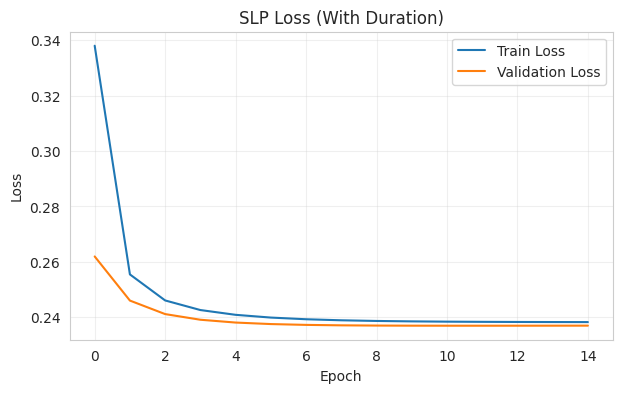

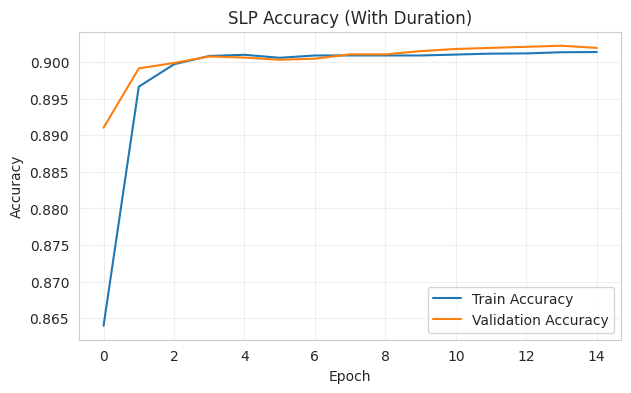


SLP validation performance:


,Metric,Validation Score
0,loss,0.236926
1,accuracy,0.901946
2,precision,0.659259
3,recall,0.336272
4,auc,0.906943



First 10 SLP validation probabilities:
[0.0277 0.0412 0.1801 0.0292 0.0088 0.0155 0.0738 0.0099 0.0496 0.0762]

First 10 SLP validation predictions:
[0 0 0 0 0 0 0 0 0 0]

Final epoch summary (SLP):
Train loss: 0.2382
Val loss: 0.2369
Train accuracy: 0.9014
Val accuracy: 0.9019

Validation comparison: SLP vs Baseline MLP


,Metric,SLP Validation,Baseline MLP Validation
0,loss,0.236926,0.203872
1,accuracy,0.901946,0.907255
2,precision,0.659259,0.641509
3,recall,0.336272,0.471033
4,auc,0.906943,0.928587


In [46]:
#  SLP baseline with duration

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import BinaryAccuracy, Precision, Recall, AUC


# 0. Safety checks

required_vars = [
    "X_train_wd_processed", "X_val_wd_processed",
    "y_train_wd_np", "y_val_wd_np",
    "baseline_val_metrics_mlp_wd"
]

missing_vars = [var for var in required_vars if var not in globals()]
if missing_vars:
    raise ValueError(
        f"These variables are missing: {missing_vars}. "
        "Please make sure Sections 8 and 9 have been run first."
    )

print("All required variables are available.")


# 1. Clear session and set seed

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)


# 2. Build SLP model

slp_wd = Sequential([
    Input(shape=(X_train_wd_processed.shape[1],)),
    Dense(1, activation="sigmoid")
])

slp_wd.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        BinaryAccuracy(name="accuracy"),
        Precision(name="precision"),
        Recall(name="recall"),
        AUC(name="auc")
    ]
)

print("SLP model built successfully.\n")
slp_wd.summary()


# 3. Train model

history_slp_wd = slp_wd.fit(
    X_train_wd_processed,
    y_train_wd_np,
    validation_data=(X_val_wd_processed, y_val_wd_np),
    epochs=15,
    batch_size=32,
    verbose=1
)


# 4. Plot training history

history_slp_df = pd.DataFrame(history_slp_wd.history)

plt.figure(figsize=(7, 4))
plt.plot(history_slp_df["loss"], label="Train Loss")
plt.plot(history_slp_df["val_loss"], label="Validation Loss")
plt.title("SLP Loss (With Duration)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_slp_df["accuracy"], label="Train Accuracy")
plt.plot(history_slp_df["val_accuracy"], label="Validation Accuracy")
plt.title("SLP Accuracy (With Duration)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# 5. Evaluate on validation set

val_results_slp_wd = slp_wd.evaluate(
    X_val_wd_processed,
    y_val_wd_np,
    verbose=0
)

metric_names = ["loss", "accuracy", "precision", "recall", "auc"]
slp_val_metrics_wd = pd.DataFrame({
    "Metric": metric_names,
    "Validation Score": val_results_slp_wd
})

print("\nSLP validation performance:")
display(slp_val_metrics_wd)


# 6. Save validation predictions

val_probs_slp_wd = slp_wd.predict(X_val_wd_processed, verbose=0).ravel()
val_preds_slp_wd = (val_probs_slp_wd >= 0.5).astype(int)

print("\nFirst 10 SLP validation probabilities:")
print(np.round(val_probs_slp_wd[:10], 4))

print("\nFirst 10 SLP validation predictions:")
print(val_preds_slp_wd[:10])


# 7. Final epoch summary

print("\nFinal epoch summary (SLP):")
print("Train loss:", round(history_slp_df['loss'].iloc[-1], 4))
print("Val loss:", round(history_slp_df['val_loss'].iloc[-1], 4))
print("Train accuracy:", round(history_slp_df['accuracy'].iloc[-1], 4))
print("Val accuracy:", round(history_slp_df['val_accuracy'].iloc[-1], 4))


# 8. Quick comparison: SLP vs Baseline MLP

comparison_df = pd.DataFrame({
    "Metric": metric_names,
    "SLP Validation": val_results_slp_wd,
    "Baseline MLP Validation": baseline_val_metrics_mlp_wd["Validation Score"].values
})

print("\nValidation comparison: SLP vs Baseline MLP")
display(comparison_df)

# Section 11: Improved MLP ANN Model (With Duration)

In this section, I develop an improved Multi-Layer Perceptron (MLP) using the feature set that includes the `duration` variable. Compared with the baseline network, this version introduces a deeper architecture, dropout regularisation, early stopping, and class weighting. These improvements are intended to reduce overfitting, address class imbalance, and improve generalisation performance.

All required variables are available.
Class weights:
{0: 0.5662372517444981, 1: 4.274311183144246}

Improved MLP model built successfully.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,017 (23.50 KB)

 Trainable params: 6,017 (23.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
989/989 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7590 - auc: 0.8686 - loss: 0.4554 - precision: 0.3055 - recall: 0.8325 - val_accuracy: 0.8085 - val_auc: 0.9150 - val_loss: 0.3676 - val_precision: 0.3675 - val_recall: 0.8816
Epoch 2/30
989/989 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8039 - auc: 0.9085 - loss: 0.3792 - precision: 0.3621 - recall: 0.8884 - val_accuracy: 0.7983 - val_auc: 0.9209 - val_loss: 0.3861 - val_precision: 0.3582 - val_recall: 0.9131
Epoch 3/30
989/989 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8098 - auc: 0.9164 - loss: 0.3607 - precision: 0.3707 - recall: 0.8971 - val_accuracy: 0.8054 - val_auc: 0.9237 - val_loss: 0.3712 - val_precision: 0.3674 - val_recall: 0.9181
Epoch 4/30
989/989 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8129 - auc: 0.9184 - loss: 0.3549 - precision: 0.3753 - recall: 0.9017 - val_accuracy: 0.8228 - val_auc: 0.9260 - val_loss: 0.3409 - val_precision: 0.3897 - val_recall: 0.9081
Epoch 5/30
989/989 ━━━━━━━━━━━━━

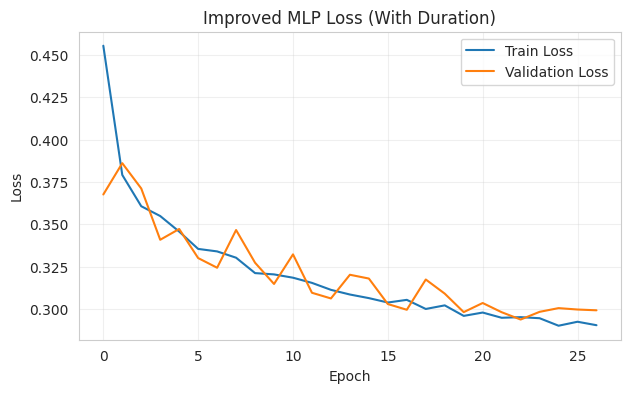

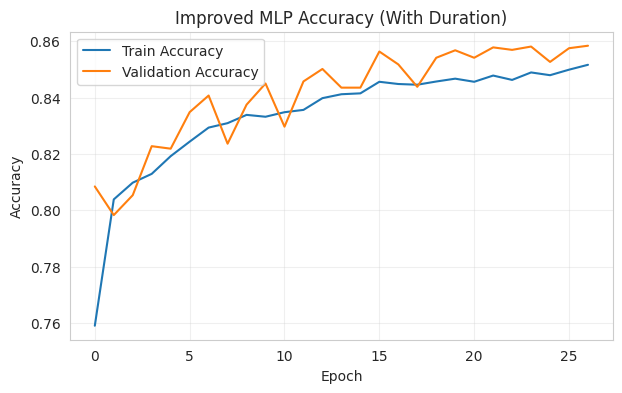


Improved MLP validation performance:


,Metric,Validation Score
0,loss,0.293844
1,accuracy,0.856974
2,precision,0.444374
3,recall,0.885390
4,auc,0.933820



First 10 improved MLP validation probabilities:
[0.0013 0.0028 0.417  0.0095 0.0038 0.0023 0.0371 0.0025 0.1295 0.4039]

First 10 improved MLP validation predictions:
[0 0 0 0 0 0 0 0 0 0]

Final epoch summary (Improved MLP):
Train loss: 0.2905
Val loss: 0.2993
Train accuracy: 0.8517
Val accuracy: 0.8584

Validation comparison: SLP vs Baseline MLP vs Improved MLP


,Metric,SLP Validation,Baseline MLP Validation,Improved MLP Validation
0,loss,0.236926,0.203872,0.293844
1,accuracy,0.901946,0.907255,0.856974
2,precision,0.659259,0.641509,0.444374
3,recall,0.336272,0.471033,0.885390
4,auc,0.906943,0.928587,0.933820


In [47]:
#  Improved MLP ANN with duration

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import BinaryAccuracy, Precision, Recall, AUC
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight


# 0. Safety checks

required_vars = [
    "X_train_wd_processed", "X_val_wd_processed",
    "y_train_wd_np", "y_val_wd_np",
    "baseline_val_metrics_mlp_wd", "slp_val_metrics_wd"
]

missing_vars = [var for var in required_vars if var not in globals()]
if missing_vars:
    raise ValueError(
        f"These variables are missing: {missing_vars}. "
        "Please make sure Sections 8, 9 and 10 have been run first."
    )

print("All required variables are available.")


# 1. Clear session and set seed

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)


# 2. Compute class weights

classes = np.unique(y_train_wd_np)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_wd_np
)

class_weight_dict = {int(cls): float(w) for cls, w in zip(classes, weights)}

print("Class weights:")
print(class_weight_dict)


# 3. Build improved MLP model

improved_mlp_wd = Sequential([
    Input(shape=(X_train_wd_processed.shape[1],)),
    Dense(64, activation="relu"),
    Dropout(0.30),
    Dense(32, activation="relu"),
    Dropout(0.20),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

improved_mlp_wd.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        BinaryAccuracy(name="accuracy"),
        Precision(name="precision"),
        Recall(name="recall"),
        AUC(name="auc")
    ]
)

print("\nImproved MLP model built successfully.\n")
improved_mlp_wd.summary()


# 4. Early stopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)


# 5. Train model

history_improved_mlp_wd = improved_mlp_wd.fit(
    X_train_wd_processed,
    y_train_wd_np,
    validation_data=(X_val_wd_processed, y_val_wd_np),
    epochs=30,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping],
    verbose=1
)

# 6. Plot training history

history_improved_df = pd.DataFrame(history_improved_mlp_wd.history)

plt.figure(figsize=(7, 4))
plt.plot(history_improved_df["loss"], label="Train Loss")
plt.plot(history_improved_df["val_loss"], label="Validation Loss")
plt.title("Improved MLP Loss (With Duration)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_improved_df["accuracy"], label="Train Accuracy")
plt.plot(history_improved_df["val_accuracy"], label="Validation Accuracy")
plt.title("Improved MLP Accuracy (With Duration)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 7. Evaluate on validation set

val_results_improved_mlp_wd = improved_mlp_wd.evaluate(
    X_val_wd_processed,
    y_val_wd_np,
    verbose=0
)

metric_names = ["loss", "accuracy", "precision", "recall", "auc"]
improved_val_metrics_mlp_wd = pd.DataFrame({
    "Metric": metric_names,
    "Validation Score": val_results_improved_mlp_wd
})

print("\nImproved MLP validation performance:")
display(improved_val_metrics_mlp_wd)

# 8. Save validation predictions

val_probs_improved_mlp_wd = improved_mlp_wd.predict(
    X_val_wd_processed,
    verbose=0
).ravel()

val_preds_improved_mlp_wd = (val_probs_improved_mlp_wd >= 0.5).astype(int)

print("\nFirst 10 improved MLP validation probabilities:")
print(np.round(val_probs_improved_mlp_wd[:10], 4))

print("\nFirst 10 improved MLP validation predictions:")
print(val_preds_improved_mlp_wd[:10])


# 9. Final epoch summary

print("\nFinal epoch summary (Improved MLP):")
print("Train loss:", round(history_improved_df['loss'].iloc[-1], 4))
print("Val loss:", round(history_improved_df['val_loss'].iloc[-1], 4))
print("Train accuracy:", round(history_improved_df['accuracy'].iloc[-1], 4))
print("Val accuracy:", round(history_improved_df['val_accuracy'].iloc[-1], 4))


# 10. Compare all three neural models

comparison_all_models = pd.DataFrame({
    "Metric": metric_names,
    "SLP Validation": slp_val_metrics_wd["Validation Score"].values,
    "Baseline MLP Validation": baseline_val_metrics_mlp_wd["Validation Score"].values,
    "Improved MLP Validation": improved_val_metrics_mlp_wd["Validation Score"].values
})

print("\nValidation comparison: SLP vs Baseline MLP vs Improved MLP")
display(comparison_all_models)

# Section 12: Test-Set Evaluation of Neural Models

In this section, I evaluate the trained neural models on the unseen test set. The purpose is to compare their final generalisation performance using multiple classification metrics, including accuracy, precision, recall, F1-score, ROC-AUC, PR-AUC, and balanced accuracy. This provides a more complete assessment than accuracy alone, especially because the dataset is imbalanced.

In [48]:
#  Test-set evaluation for SLP, baseline MLP, and improved MLP

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score
)


# 0. Safety checks

required_vars = [
    "slp_wd", "baseline_mlp_wd", "improved_mlp_wd",
    "X_test_wd_processed", "y_test_wd_np"
]

missing_vars = [var for var in required_vars if var not in globals()]
if missing_vars:
    raise ValueError(
        f"These variables are missing: {missing_vars}. "
        "Please make sure Sections 8, 9, 10 and 11 have been run first."
    )

print("All required variables are available.")


# 1. Generate probabilities and predictions

test_probs_slp_wd = slp_wd.predict(X_test_wd_processed, verbose=0).ravel()
test_probs_baseline_mlp_wd = baseline_mlp_wd.predict(X_test_wd_processed, verbose=0).ravel()
test_probs_improved_mlp_wd = improved_mlp_wd.predict(X_test_wd_processed, verbose=0).ravel()

test_preds_slp_wd = (test_probs_slp_wd >= 0.5).astype(int)
test_preds_baseline_mlp_wd = (test_probs_baseline_mlp_wd >= 0.5).astype(int)
test_preds_improved_mlp_wd = (test_probs_improved_mlp_wd >= 0.5).astype(int)


# 2. Evaluation helper

def evaluate_binary_model(model_name, y_true, y_pred, y_prob):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob)
    }


# 3. Build test results table

test_results = pd.DataFrame([
    evaluate_binary_model("SLP (with duration)", y_test_wd_np, test_preds_slp_wd, test_probs_slp_wd),
    evaluate_binary_model("Baseline MLP (with duration)", y_test_wd_np, test_preds_baseline_mlp_wd, test_probs_baseline_mlp_wd),
    evaluate_binary_model("Improved MLP (with duration)", y_test_wd_np, test_preds_improved_mlp_wd, test_probs_improved_mlp_wd)
])

test_results_rounded = test_results.copy()
metric_cols = [col for col in test_results.columns if col != "Model"]
test_results_rounded[metric_cols] = test_results_rounded[metric_cols].round(4)

print("Test-set evaluation results:")
display(test_results_rounded)


# 4. Quick ranking by key metrics

print("Best model by Accuracy:", test_results.sort_values("Accuracy", ascending=False).iloc[0]["Model"])
print("Best model by Recall:", test_results.sort_values("Recall", ascending=False).iloc[0]["Model"])
print("Best model by F1-Score:", test_results.sort_values("F1-Score", ascending=False).iloc[0]["Model"])
print("Best model by ROC-AUC:", test_results.sort_values("ROC-AUC", ascending=False).iloc[0]["Model"])
print("Best model by PR-AUC:", test_results.sort_values("PR-AUC", ascending=False).iloc[0]["Model"])


# 5. Save results for later sections

test_results_neural_models = test_results_rounded.copy()

print("\nFirst 10 test probabilities from each model:")
print("SLP:", np.round(test_probs_slp_wd[:10], 4))
print("Baseline MLP:", np.round(test_probs_baseline_mlp_wd[:10], 4))
print("Improved MLP:", np.round(test_probs_improved_mlp_wd[:10], 4))

All required variables are available.
Test-set evaluation results:


,Model,Accuracy,Precision,Recall,F1-Score,Balanced Accuracy,ROC-AUC,PR-AUC
0,SLP (with duration),0.9003,0.6430,0.3317,0.4376,0.6536,0.9036,0.5343
1,Baseline MLP (with duration),0.9024,0.6116,0.4527,0.5203,0.7073,0.9188,0.5737
2,Improved MLP (with duration),0.8408,0.4133,0.8625,0.5588,0.8502,0.9215,0.5947


Best model by Accuracy: Baseline MLP (with duration)
Best model by Recall: Improved MLP (with duration)
Best model by F1-Score: Improved MLP (with duration)
Best model by ROC-AUC: Improved MLP (with duration)
Best model by PR-AUC: Improved MLP (with duration)

First 10 test probabilities from each model:
SLP: [0.0231 0.0374 0.0576 0.0067 0.7442 0.0741 0.1002 0.0564 0.0672 0.7777]
Baseline MLP: [3.000e-04 4.400e-03 3.870e-02 0.000e+00 6.137e-01 5.300e-03 4.669e-01
 2.000e-04 1.490e-02 2.980e-01]
Improved MLP: [0.     0.02   0.1107 0.     0.8879 0.0033 0.6819 0.0075 0.028  0.8515]


# Section 13: Confusion Matrix Analysis

In this section, I analyse the prediction behaviour of the trained neural models using confusion matrices and classification reports. This helps identify how each model handles true positives, true negatives, false positives, and false negatives, which is especially important for understanding performance on the minority class.

All required variables are available.

SLP (with duration)
Confusion Matrix:
[[5843  146]
 [ 530  263]]
TN = 5843, FP = 146, FN = 530, TP = 263


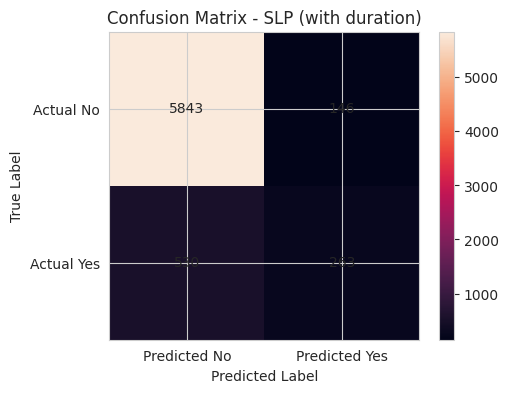

Classification Report:


,precision,recall,f1-score,support
no,0.9168,0.9756,0.9453,5989.0000
yes,0.6430,0.3317,0.4376,793.0000
accuracy,0.9003,0.9003,0.9003,0.9003
macro avg,0.7799,0.6536,0.6915,6782.0000
weighted avg,0.8848,0.9003,0.8860,6782.0000



Baseline MLP (with duration)
Confusion Matrix:
[[5761  228]
 [ 434  359]]
TN = 5761, FP = 228, FN = 434, TP = 359


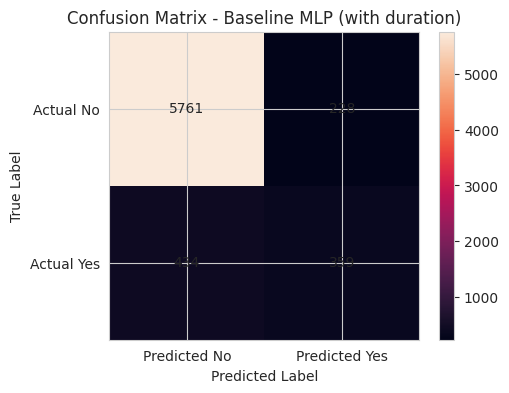

Classification Report:


,precision,recall,f1-score,support
no,0.9299,0.9619,0.9457,5989.0000
yes,0.6116,0.4527,0.5203,793.0000
accuracy,0.9024,0.9024,0.9024,0.9024
macro avg,0.7708,0.7073,0.7330,6782.0000
weighted avg,0.8927,0.9024,0.8959,6782.0000



Improved MLP (with duration)
Confusion Matrix:
[[5018  971]
 [ 109  684]]
TN = 5018, FP = 971, FN = 109, TP = 684


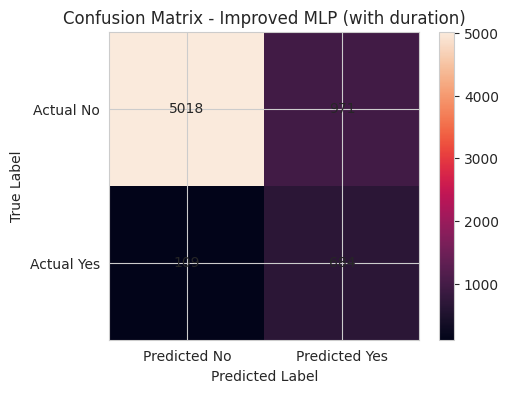

Classification Report:


,precision,recall,f1-score,support
no,0.9787,0.8379,0.9028,5989.0000
yes,0.4133,0.8625,0.5588,793.0000
accuracy,0.8408,0.8408,0.8408,0.8408
macro avg,0.6960,0.8502,0.7308,6782.0000
weighted avg,0.9126,0.8408,0.8626,6782.0000



Confusion matrix summary table:


,Model,TN,FP,FN,TP
0,SLP (with duration),5843,146,530,263
1,Baseline MLP (with duration),5761,228,434,359
2,Improved MLP (with duration),5018,971,109,684



Confusion matrix summary with error rates:


,Model,TN,FP,FN,TP,False Positive Rate,False Negative Rate
0,SLP (with duration),5843,146,530,263,0.0244,0.6683
1,Baseline MLP (with duration),5761,228,434,359,0.0381,0.5473
2,Improved MLP (with duration),5018,971,109,684,0.1621,0.1375


In [49]:
#  Confusion matrix analysis for all 3 neural models

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report

# 0. Safety checks

required_vars = [
    "y_test_wd_np",
    "test_preds_slp_wd",
    "test_preds_baseline_mlp_wd",
    "test_preds_improved_mlp_wd"
]

missing_vars = [var for var in required_vars if var not in globals()]
if missing_vars:
    raise ValueError(
        f"These variables are missing: {missing_vars}. "
        "Please run Section 12 first."
    )

print("All required variables are available.")


# 1. Helper function

def plot_confusion_and_report(model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n{'='*70}")
    print(f"{model_name}")
    print(f"{'='*70}")
    print("Confusion Matrix:")
    print(cm)
    print(f"TN = {tn}, FP = {fp}, FN = {fn}, TP = {tp}")

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest", aspect="auto")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.colorbar()
    plt.xticks([0, 1], ["Predicted No", "Predicted Yes"])
    plt.yticks([0, 1], ["Actual No", "Actual Yes"])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    report = classification_report(
        y_true, y_pred,
        target_names=["no", "yes"],
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report).T
    print("Classification Report:")
    display(report_df.round(4))

    return {
        "Model": model_name,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }


# 2. Run for all 3 models

cm_results = []

cm_results.append(
    plot_confusion_and_report("SLP (with duration)", y_test_wd_np, test_preds_slp_wd)
)

cm_results.append(
    plot_confusion_and_report("Baseline MLP (with duration)", y_test_wd_np, test_preds_baseline_mlp_wd)
)

cm_results.append(
    plot_confusion_and_report("Improved MLP (with duration)", y_test_wd_np, test_preds_improved_mlp_wd)
)


# 3. Summary table

cm_summary_df = pd.DataFrame(cm_results)

print("\nConfusion matrix summary table:")
display(cm_summary_df)

# Optional rates
cm_summary_df["False Positive Rate"] = (cm_summary_df["FP"] / (cm_summary_df["FP"] + cm_summary_df["TN"])).round(4)
cm_summary_df["False Negative Rate"] = (cm_summary_df["FN"] / (cm_summary_df["FN"] + cm_summary_df["TP"])).round(4)

print("\nConfusion matrix summary with error rates:")
display(cm_summary_df)

# Section 14: Ambiguity and Uncertainty Analysis

In this section, I analyse prediction confidence and ambiguity using the probability outputs of the neural network models. Predictions close to 0.5 are treated as uncertain because the model is less confident in assigning them to either class. This helps identify ambiguous cases, compare confidence behaviour across models, and highlight samples that may be more difficult to classify reliably.

All required variables are available.
Uncertainty summary:


,Model,Total Samples,Ambiguous Samples,Ambiguous %,Accuracy Overall,Accuracy on Ambiguous Samples,Accuracy on Confident Samples,Mean Probability,Mean Uncertainty Score
0,SLP,6782,197,2.90,0.9003,0.4569,0.9136,0.1120,0.4168
1,Baseline MLP,6782,488,7.20,0.9024,0.5430,0.9303,0.1166,0.4096
2,Improved MLP,6782,392,5.78,0.8408,0.5128,0.8609,0.2418,0.3971


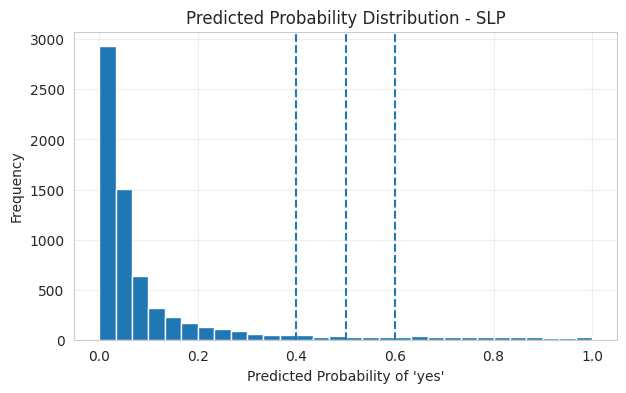

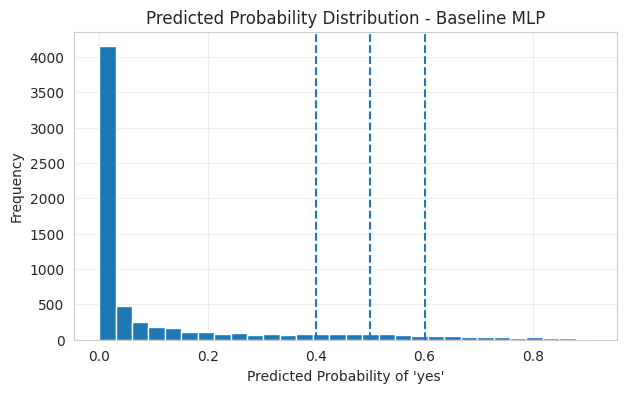

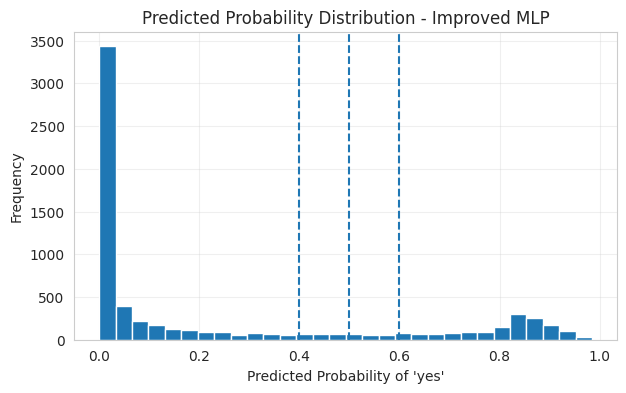

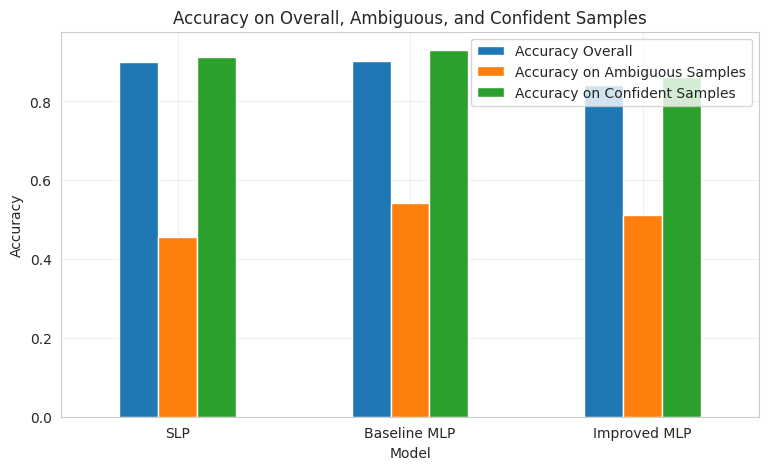

Top 15 most ambiguous samples - Improved MLP:


,Model,y_true,y_pred,prob_yes,correct,uncertainty_score,is_ambiguous,distance_to_0_5
759,Improved MLP,0,1,0.500101,0,0.000101,1,0.000101
390,Improved MLP,0,1,0.500275,0,0.000275,1,0.000275
5777,Improved MLP,0,0,0.499495,1,0.000505,1,0.000505
4543,Improved MLP,0,0,0.499245,1,0.000755,1,0.000755
1469,Improved MLP,1,0,0.499177,0,0.000823,1,0.000823
2909,Improved MLP,0,0,0.499107,1,0.000893,1,0.000893
6088,Improved MLP,1,1,0.501660,1,0.001660,1,0.001660
6117,Improved MLP,1,1,0.501756,1,0.001756,1,0.001756
2771,Improved MLP,0,0,0.497862,1,0.002138,1,0.002138
5390,Improved MLP,0,1,0.502242,0,0.002242,1,0.002242


Top 15 wrong predictions with highest confidence - Improved MLP:


,Model,y_true,y_pred,prob_yes,correct,uncertainty_score,is_ambiguous,confidence_strength
1741,Improved MLP,1,0,0.000344,0,0.499656,0,0.499656
2987,Improved MLP,1,0,0.002347,0,0.497653,0,0.497653
1324,Improved MLP,1,0,0.002481,0,0.497519,0,0.497519
5232,Improved MLP,1,0,0.004646,0,0.495354,0,0.495354
4034,Improved MLP,1,0,0.005593,0,0.494407,0,0.494407
3237,Improved MLP,1,0,0.006240,0,0.493760,0,0.493760
6204,Improved MLP,1,0,0.006732,0,0.493268,0,0.493268
4708,Improved MLP,1,0,0.007786,0,0.492214,0,0.492214
3212,Improved MLP,1,0,0.013706,0,0.486294,0,0.486294
4347,Improved MLP,1,0,0.015662,0,0.484338,0,0.484338


Interpretation guide:
- Samples with probabilities near 0.5 are more ambiguous.
- Samples with probabilities near 0 or 1 are more confident.
- Lower accuracy on ambiguous cases would indicate that uncertainty is meaningful.
- Highly confident but wrong predictions are especially important for error analysis.


In [50]:
# Ambiguity / uncertainty analysis for all 3 neural models

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# 0. Safety checks

required_vars = [
    "y_test_wd_np",
    "test_probs_slp_wd", "test_preds_slp_wd",
    "test_probs_baseline_mlp_wd", "test_preds_baseline_mlp_wd",
    "test_probs_improved_mlp_wd", "test_preds_improved_mlp_wd"
]

missing_vars = [var for var in required_vars if var not in globals()]
if missing_vars:
    raise ValueError(
        f"These variables are missing: {missing_vars}. "
        "Please run Sections 12 and 13 first."
    )

print("All required variables are available.")


# 1. Helper function

def build_uncertainty_df(model_name, y_true, y_pred, y_prob, low=0.40, high=0.60):
    df_u = pd.DataFrame({
        "Model": model_name,
        "y_true": y_true.astype(int),
        "y_pred": y_pred.astype(int),
        "prob_yes": y_prob
    })

    df_u["correct"] = (df_u["y_true"] == df_u["y_pred"]).astype(int)
    df_u["uncertainty_score"] = np.abs(df_u["prob_yes"] - 0.5)
    df_u["is_ambiguous"] = ((df_u["prob_yes"] >= low) & (df_u["prob_yes"] <= high)).astype(int)

    return df_u


# 2. Build uncertainty dataframes

unc_slp = build_uncertainty_df("SLP", y_test_wd_np, test_preds_slp_wd, test_probs_slp_wd)
unc_baseline = build_uncertainty_df("Baseline MLP", y_test_wd_np, test_preds_baseline_mlp_wd, test_probs_baseline_mlp_wd)
unc_improved = build_uncertainty_df("Improved MLP", y_test_wd_np, test_preds_improved_mlp_wd, test_probs_improved_mlp_wd)

uncertainty_all = pd.concat([unc_slp, unc_baseline, unc_improved], ignore_index=True)


# 3. Summary function

def uncertainty_summary(df_u):
    ambiguous_df = df_u[df_u["is_ambiguous"] == 1]
    confident_df = df_u[df_u["is_ambiguous"] == 0]

    return {
        "Model": df_u["Model"].iloc[0],
        "Total Samples": len(df_u),
        "Ambiguous Samples": len(ambiguous_df),
        "Ambiguous %": round(len(ambiguous_df) / len(df_u) * 100, 2),
        "Accuracy Overall": round(df_u["correct"].mean(), 4),
        "Accuracy on Ambiguous Samples": round(ambiguous_df["correct"].mean(), 4) if len(ambiguous_df) > 0 else np.nan,
        "Accuracy on Confident Samples": round(confident_df["correct"].mean(), 4) if len(confident_df) > 0 else np.nan,
        "Mean Probability": round(df_u["prob_yes"].mean(), 4),
        "Mean Uncertainty Score": round(df_u["uncertainty_score"].mean(), 4)
    }

uncertainty_summary_df = pd.DataFrame([
    uncertainty_summary(unc_slp),
    uncertainty_summary(unc_baseline),
    uncertainty_summary(unc_improved)
])

print("Uncertainty summary:")
display(uncertainty_summary_df)


# 4. Probability histograms

for model_name, df_u in [
    ("SLP", unc_slp),
    ("Baseline MLP", unc_baseline),
    ("Improved MLP", unc_improved)
]:
    plt.figure(figsize=(7, 4))
    plt.hist(df_u["prob_yes"], bins=30)
    plt.title(f"Predicted Probability Distribution - {model_name}")
    plt.xlabel("Predicted Probability of 'yes'")
    plt.ylabel("Frequency")
    plt.axvline(0.4, linestyle="--")
    plt.axvline(0.5, linestyle="--")
    plt.axvline(0.6, linestyle="--")
    plt.grid(True, alpha=0.3)
    plt.show()


# 5. Compare ambiguous vs confident accuracy

comparison_plot_df = uncertainty_summary_df.set_index("Model")[[
    "Accuracy Overall",
    "Accuracy on Ambiguous Samples",
    "Accuracy on Confident Samples"
]]

comparison_plot_df.plot(kind="bar", figsize=(9, 5))
plt.title("Accuracy on Overall, Ambiguous, and Confident Samples")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.show()


# 6. Most ambiguous samples for improved MLP

most_ambiguous_improved = unc_improved.copy()
most_ambiguous_improved["distance_to_0_5"] = np.abs(most_ambiguous_improved["prob_yes"] - 0.5)
most_ambiguous_improved = most_ambiguous_improved.sort_values("distance_to_0_5")

print("Top 15 most ambiguous samples - Improved MLP:")
display(most_ambiguous_improved.head(15))


# 7. Wrong predictions with highest confidence - Improved MLP

wrong_high_conf_improved = unc_improved[unc_improved["correct"] == 0].copy()
wrong_high_conf_improved["confidence_strength"] = np.abs(wrong_high_conf_improved["prob_yes"] - 0.5)
wrong_high_conf_improved = wrong_high_conf_improved.sort_values("confidence_strength", ascending=False)

print("Top 15 wrong predictions with highest confidence - Improved MLP:")
display(wrong_high_conf_improved.head(15))


# 8. Compact interpretation

print("Interpretation guide:")
print("- Samples with probabilities near 0.5 are more ambiguous.")
print("- Samples with probabilities near 0 or 1 are more confident.")
print("- Lower accuracy on ambiguous cases would indicate that uncertainty is meaningful.")
print("- Highly confident but wrong predictions are especially important for error analysis.")

# Section 15: Error Analysis and Final Model Selection

In this section, I examine the types of mistakes made by the strongest neural models and use the full evaluation evidence to select a final model. This includes reviewing false positives and false negatives, identifying practical trade-offs, and deciding which model is most suitable for the problem objective.

In [51]:
#  Error analysis and final model selection

import pandas as pd
import numpy as np


# 0. Safety checks

required_vars = [
    "X_test_wd", "y_test_wd",
    "test_probs_baseline_mlp_wd", "test_preds_baseline_mlp_wd",
    "test_probs_improved_mlp_wd", "test_preds_improved_mlp_wd",
    "test_results_neural_models", "cm_summary_df", "uncertainty_summary_df"
]

missing_vars = [var for var in required_vars if var not in globals()]
if missing_vars:
    raise ValueError(
        f"These variables are missing: {missing_vars}. "
        "Please run Sections 12, 13, and 14 first."
    )

print("All required variables are available.")


# 1. Build detailed error tables

baseline_error_df = X_test_wd.copy()
baseline_error_df["y_true"] = y_test_wd.values
baseline_error_df["y_pred"] = test_preds_baseline_mlp_wd
baseline_error_df["prob_yes"] = test_probs_baseline_mlp_wd
baseline_error_df["correct"] = (baseline_error_df["y_true"] == baseline_error_df["y_pred"]).astype(int)

improved_error_df = X_test_wd.copy()
improved_error_df["y_true"] = y_test_wd.values
improved_error_df["y_pred"] = test_preds_improved_mlp_wd
improved_error_df["prob_yes"] = test_probs_improved_mlp_wd
improved_error_df["correct"] = (improved_error_df["y_true"] == improved_error_df["y_pred"]).astype(int)

# 2. Extract key error groups

baseline_false_positives = baseline_error_df[(baseline_error_df["y_true"] == 0) & (baseline_error_df["y_pred"] == 1)].copy()
baseline_false_negatives = baseline_error_df[(baseline_error_df["y_true"] == 1) & (baseline_error_df["y_pred"] == 0)].copy()

improved_false_positives = improved_error_df[(improved_error_df["y_true"] == 0) & (improved_error_df["y_pred"] == 1)].copy()
improved_false_negatives = improved_error_df[(improved_error_df["y_true"] == 1) & (improved_error_df["y_pred"] == 0)].copy()

# Sort by confidence
baseline_false_positives = baseline_false_positives.sort_values("prob_yes", ascending=False)
baseline_false_negatives = baseline_false_negatives.sort_values("prob_yes", ascending=True)

improved_false_positives = improved_false_positives.sort_values("prob_yes", ascending=False)
improved_false_negatives = improved_false_negatives.sort_values("prob_yes", ascending=True)


# 3. Show top errors

print("Top 10 highest-confidence FALSE POSITIVES - Baseline MLP")
display(baseline_false_positives[[
    "age", "job", "marital", "education", "balance", "contact",
    "duration", "campaign", "poutcome", "was_previously_contacted",
    "pdays_clean", "y_true", "y_pred", "prob_yes"
]].head(10))

print("Top 10 highest-confidence FALSE NEGATIVES - Baseline MLP")
display(baseline_false_negatives[[
    "age", "job", "marital", "education", "balance", "contact",
    "duration", "campaign", "poutcome", "was_previously_contacted",
    "pdays_clean", "y_true", "y_pred", "prob_yes"
]].head(10))

print("Top 10 highest-confidence FALSE POSITIVES - Improved MLP")
display(improved_false_positives[[
    "age", "job", "marital", "education", "balance", "contact",
    "duration", "campaign", "poutcome", "was_previously_contacted",
    "pdays_clean", "y_true", "y_pred", "prob_yes"
]].head(10))

print("Top 10 highest-confidence FALSE NEGATIVES - Improved MLP")
display(improved_false_negatives[[
    "age", "job", "marital", "education", "balance", "contact",
    "duration", "campaign", "poutcome", "was_previously_contacted",
    "pdays_clean", "y_true", "y_pred", "prob_yes"
]].head(10))


# 4. Final comparison summary

final_summary = test_results_neural_models.merge(
    cm_summary_df[["Model", "FP", "FN", "TP", "TN"]],
    on="Model",
    how="left"
).merge(
    uncertainty_summary_df[["Model", "Ambiguous %", "Accuracy on Ambiguous Samples", "Accuracy on Confident Samples"]],
    on="Model",
    how="left"
)

print("Final model comparison summary:")
display(final_summary)


# 5. Recommendation logic

print("Final model selection guidance:")
print("- SLP is the weakest overall and mainly serves as a simple neural baseline.")
print("- Baseline MLP gives the best raw accuracy and a more conservative prediction profile.")
print("- Improved MLP gives the best recall, F1-score, balanced accuracy, ROC-AUC, and PR-AUC.")
print("- Improved MLP is better if the main objective is to identify as many true subscribers as possible.")
print("- Baseline MLP is better if the main objective is to reduce false positives and keep predictions conservative.")

# Recommended final choice for imbalanced classification
recommended_model = "Improved MLP (with duration)"
print(f"\nRecommended final model for this imbalanced classification task: {recommended_model}")


# 6. Final concise conclusion text

final_conclusion = [
    "The SLP underperformed compared with the deeper neural networks, indicating that a single linear decision layer was insufficient for this problem.",
    "The baseline MLP achieved the highest accuracy, showing strong overall discrimination while remaining relatively conservative.",
    "The improved MLP achieved the best recall, F1-score, balanced accuracy, ROC-AUC, and PR-AUC, making it the strongest model for identifying the minority 'yes' class.",
    "Therefore, the improved MLP is selected as the final model when the main objective is effective detection of likely subscribers in an imbalanced dataset."
]

print("\nFinal conclusion points:")
for line in final_conclusion:
    print("-", line)

All required variables are available.
Top 10 highest-confidence FALSE POSITIVES - Baseline MLP


,age,job,marital,education,balance,contact,duration,campaign,poutcome,was_previously_contacted,pdays_clean,y_true,y_pred,prob_yes
34171,27,admin.,married,tertiary,73,cellular,374,1,success,1,79,0,1,0.907073
44028,39,management,married,tertiary,2939,cellular,385,1,success,1,165,0,1,0.898126
42143,38,unemployed,married,tertiary,2812,cellular,322,1,success,1,187,0,1,0.882834
43215,68,retired,married,tertiary,2820,cellular,158,1,success,1,92,0,1,0.876403
33991,57,admin.,married,secondary,169,cellular,319,1,success,1,86,0,1,0.871347
40711,57,services,married,secondary,2476,cellular,239,1,success,1,459,0,1,0.871040
43340,37,technician,married,secondary,1458,cellular,344,1,success,1,326,0,1,0.864714
40628,47,management,married,tertiary,699,cellular,432,3,success,1,97,0,1,0.860013
42709,76,retired,married,tertiary,2991,cellular,195,1,success,1,95,0,1,0.859672
42937,56,admin.,married,unknown,2038,cellular,405,1,success,1,305,0,1,0.858096


Top 10 highest-confidence FALSE NEGATIVES - Baseline MLP


,age,job,marital,education,balance,contact,duration,campaign,poutcome,was_previously_contacted,pdays_clean,y_true,y_pred,prob_yes
3324,49,unknown,married,primary,341,unknown,520,2,unknown,0,0,1,0,0.000527
27715,23,unemployed,single,primary,1003,telephone,8,1,unknown,0,0,1,0,0.000786
13807,47,blue-collar,married,secondary,182,telephone,39,1,unknown,0,0,1,0,0.001075
41205,34,technician,married,tertiary,197,cellular,78,3,unknown,0,0,1,0,0.001106
44124,53,admin.,single,secondary,654,unknown,67,1,unknown,0,0,1,0,0.001227
40082,38,entrepreneur,divorced,secondary,1190,cellular,81,2,failure,1,391,1,0,0.001633
42326,40,admin.,married,tertiary,764,unknown,85,1,unknown,0,0,1,0,0.002187
41070,45,management,married,tertiary,2671,cellular,94,4,unknown,0,0,1,0,0.002874
42799,60,retired,married,secondary,18967,cellular,177,2,unknown,0,0,1,0,0.002901
38103,34,services,single,secondary,2,cellular,153,2,unknown,0,0,1,0,0.004775


Top 10 highest-confidence FALSE POSITIVES - Improved MLP


...

Top 10 highest-confidence FALSE NEGATIVES - Improved MLP


,age,job,marital,education,balance,contact,duration,campaign,poutcome,was_previously_contacted,pdays_clean,y_true,y_pred,prob_yes
27715,23,unemployed,single,primary,1003,telephone,8,1,unknown,0,0,1,0,0.000344
3324,49,unknown,married,primary,341,unknown,520,2,unknown,0,0,1,0,0.002347
41205,34,technician,married,tertiary,197,cellular,78,3,unknown,0,0,1,0,0.002481
13807,47,blue-collar,married,secondary,182,telephone,39,1,unknown,0,0,1,0,0.004646
41070,45,management,married,tertiary,2671,cellular,94,4,unknown,0,0,1,0,0.005593
22255,55,blue-collar,married,secondary,196,cellular,81,1,unknown,0,0,1,0,0.006240
40082,38,entrepreneur,divorced,secondary,1190,cellular,81,2,failure,1,391,1,0,0.006732
44124,53,admin.,single,secondary,654,unknown,67,1,unknown,0,0,1,0,0.007786
21422,58,retired,married,primary,1241,cellular,194,2,unknown,0,0,1,0,0.013706
44392,48,housemaid,single,primary,46,cellular,113,2,failure,1,180,1,0,0.015662


Final model comparison summary:


,Model,Accuracy,Precision,Recall,F1-Score,Balanced Accuracy,ROC-AUC,PR-AUC,FP,FN,TP,TN,Ambiguous %,Accuracy on Ambiguous Samples,Accuracy on Confident Samples
0,SLP (with duration),0.9003,0.6430,0.3317,0.4376,0.6536,0.9036,0.5343,146,530,263,5843,NaN,NaN,NaN
1,Baseline MLP (with duration),0.9024,0.6116,0.4527,0.5203,0.7073,0.9188,0.5737,228,434,359,5761,NaN,NaN,NaN
2,Improved MLP (with duration),0.8408,0.4133,0.8625,0.5588,0.8502,0.9215,0.5947,971,109,684,5018,NaN,NaN,NaN


Final model selection guidance:
- SLP is the weakest overall and mainly serves as a simple neural baseline.
- Baseline MLP gives the best raw accuracy and a more conservative prediction profile.
- Improved MLP gives the best recall, F1-score, balanced accuracy, ROC-AUC, and PR-AUC.
- Improved MLP is better if the main objective is to identify as many true subscribers as possible.
- Baseline MLP is better if the main objective is to reduce false positives and keep predictions conservative.

Recommended final model for this imbalanced classification task: Improved MLP (with duration)

Final conclusion points:
- The SLP underperformed compared with the deeper neural networks, indicating that a single linear decision layer was insufficient for this problem.
- The baseline MLP achieved the highest accuracy, showing strong overall discrimination while remaining relatively conservative.
- The improved MLP achieved the best recall, F1-score, balanced accuracy, ROC-AUC, and PR-AUC, making it th

## Corrected final comparison summary

This cell fixes the model-name alignment issue so that the uncertainty metrics can be merged correctly into the final model comparison table.


In [52]:
# Fix model-name mismatch for final summary merge

uncertainty_summary_fixed = uncertainty_summary_df.copy()

uncertainty_summary_fixed["Model"] = uncertainty_summary_fixed["Model"].replace({
    "SLP": "SLP (with duration)",
    "Baseline MLP": "Baseline MLP (with duration)",
    "Improved MLP": "Improved MLP (with duration)"
})

final_summary_fixed = test_results_neural_models.merge(
    cm_summary_df[["Model", "FP", "FN", "TP", "TN"]],
    on="Model",
    how="left"
).merge(
    uncertainty_summary_fixed[["Model", "Ambiguous %", "Accuracy on Ambiguous Samples", "Accuracy on Confident Samples"]],
    on="Model",
    how="left"
)

print("Corrected final model comparison summary:")
display(final_summary_fixed)

Corrected final model comparison summary:


,Model,Accuracy,Precision,Recall,F1-Score,Balanced Accuracy,ROC-AUC,PR-AUC,FP,FN,TP,TN,Ambiguous %,Accuracy on Ambiguous Samples,Accuracy on Confident Samples
0,SLP (with duration),0.9003,0.6430,0.3317,0.4376,0.6536,0.9036,0.5343,146,530,263,5843,2.90,0.4569,0.9136
1,Baseline MLP (with duration),0.9024,0.6116,0.4527,0.5203,0.7073,0.9188,0.5737,228,434,359,5761,7.20,0.5430,0.9303
2,Improved MLP (with duration),0.8408,0.4133,0.8625,0.5588,0.8502,0.9215,0.5947,971,109,684,5018,5.78,0.5128,0.8609


# Section 16: Final Outputs and Export

In this section, I save the final project outputs, including the selected model, preprocessing object, and result tables. This helps preserve the final workflow for reuse, reproducibility, and reporting.

In [53]:
# Save/export final outputs

import os
import joblib
import pandas as pd
import numpy as np


# 1. Create output folders

os.makedirs("outputs", exist_ok=True)
os.makedirs("models", exist_ok=True)


# 2. Save result tables

test_results_neural_models.to_csv("outputs/test_results_neural_models.csv", index=False)
cm_summary_df.to_csv("outputs/confusion_matrix_summary.csv", index=False)
uncertainty_summary_df.to_csv("outputs/uncertainty_summary.csv", index=False)
final_summary_fixed.to_csv("outputs/final_model_comparison_summary.csv", index=False)


# 3. Save important error-analysis tables

baseline_false_positives.to_csv("outputs/baseline_false_positives.csv", index=False)
baseline_false_negatives.to_csv("outputs/baseline_false_negatives.csv", index=False)
improved_false_positives.to_csv("outputs/improved_false_positives.csv", index=False)
improved_false_negatives.to_csv("outputs/improved_false_negatives.csv", index=False)


# 4. Save most ambiguous / high-confidence wrong cases

most_ambiguous_improved.to_csv("outputs/most_ambiguous_improved.csv", index=False)
wrong_high_conf_improved.to_csv("outputs/high_confidence_wrong_improved.csv", index=False)


# 5. Save chosen final model and preprocessor

improved_mlp_wd.save("models/final_improved_mlp_with_duration.keras")
joblib.dump(preprocessor_wd, "models/preprocessor_with_duration.joblib")


# 6. Save feature names

pd.Series(feature_names_wd).to_csv("outputs/feature_names_with_duration.csv", index=False)


# 7. Final notebook summary

print("Files saved successfully.\n")

print("Saved model:")
print("- models/final_improved_mlp_with_duration.keras")

print("\nSaved preprocessor:")
print("- models/preprocessor_with_duration.joblib")

print("\nSaved result files:")
print("- outputs/test_results_neural_models.csv")
print("- outputs/confusion_matrix_summary.csv")
print("- outputs/uncertainty_summary.csv")
print("- outputs/final_model_comparison_summary.csv")
print("- outputs/baseline_false_positives.csv")
print("- outputs/baseline_false_negatives.csv")
print("- outputs/improved_false_positives.csv")
print("- outputs/improved_false_negatives.csv")
print("- outputs/most_ambiguous_improved.csv")
print("- outputs/high_confidence_wrong_improved.csv")
print("- outputs/feature_names_with_duration.csv")

print("\nFinal selected model:")
print("Improved MLP (with duration)")

Files saved successfully.

Saved model:
- models/final_improved_mlp_with_duration.keras

Saved preprocessor:
- models/preprocessor_with_duration.joblib

Saved result files:
- outputs/test_results_neural_models.csv
- outputs/confusion_matrix_summary.csv
- outputs/uncertainty_summary.csv
- outputs/final_model_comparison_summary.csv
- outputs/baseline_false_positives.csv
- outputs/baseline_false_negatives.csv
- outputs/improved_false_positives.csv
- outputs/improved_false_negatives.csv
- outputs/most_ambiguous_improved.csv
- outputs/high_confidence_wrong_improved.csv
- outputs/feature_names_with_duration.csv

Final selected model:
Improved MLP (with duration)
